## **Evolutionary Computation Methods in Image Processing**

### **Generative Art and Image Reconstruction with (1+1) hill-climber**

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ==========================================================
# CONFIG
# ==========================================================

IMAGE = "images/lena.jpg"

SIZE = 128
N_TRIANGLES = 150          # final triangle count
START_TRIANGLES = 15       # progressive growth: start small
GROW_EVERY = 1500          # add 1 triangle every N generations until N_TRIANGLES reached

GENERATIONS = 250000       # (1+1) hill-climbing needs MANY more iterations than 50k
SHOW_EVERY = 5000

# mutation step sizes decay over the run (coarse -> fine search)
VERTEX_SIGMA_START, VERTEX_SIGMA_END = 12, 2
COLOR_SIGMA_START, COLOR_SIGMA_END = 40, 8
ALPHA_SIGMA_START, ALPHA_SIGMA_END = 20, 5

REINIT_PROB = 0.02   # chance to fully randomize a triangle instead of nudging it
                      # (escapes local optima that pure jitter can't)

np.random.seed(42)

# ==========================================================
# LOAD TARGET IMAGE
# ==========================================================

target = cv2.imread(IMAGE)
if target is None:
    raise FileNotFoundError(IMAGE)

target = cv2.cvtColor(target, cv2.COLOR_BGR2RGB)
target = cv2.resize(target, (SIZE, SIZE)).astype(np.float32)

# ==========================================================
# CHROMOSOME FORMAT (per triangle): x1 y1 x2 y2 x3 y3 R G B alpha
# ==========================================================

GENES = 10


def random_triangle():
    t = np.empty(GENES, dtype=np.float32)
    t[0:6] = np.random.randint(0, SIZE, 6)
    t[6:9] = np.random.randint(0, 256, 3)
    t[9] = np.random.randint(20, 120)
    return t


def seed_triangle():
    """
    Used when GROWING the population mid-run. Unlike random_triangle(),
    this creates a SMALL, mostly-transparent triangle whose color is
    sampled from the target image at that spot. A newly added triangle
    must not visibly disrupt an already-refined image -- it should blend
    in almost invisibly and get sharpened up by later mutations.
    """
    cx = np.random.randint(0, SIZE)
    cy = np.random.randint(0, SIZE)
    spread = np.random.randint(6, 18)  # small local triangle, not canvas-spanning

    t = np.empty(GENES, dtype=np.float32)
    t[0] = np.clip(cx + np.random.randint(-spread, spread), 0, SIZE - 1)
    t[1] = np.clip(cy + np.random.randint(-spread, spread), 0, SIZE - 1)
    t[2] = np.clip(cx + np.random.randint(-spread, spread), 0, SIZE - 1)
    t[3] = np.clip(cy + np.random.randint(-spread, spread), 0, SIZE - 1)
    t[4] = np.clip(cx + np.random.randint(-spread, spread), 0, SIZE - 1)
    t[5] = np.clip(cy + np.random.randint(-spread, spread), 0, SIZE - 1)

    # sample color from the target at the centroid so it blends in immediately
    t[6:9] = target[cy, cx, :]

    t[9] = np.random.randint(10, 40)  # low alpha -> barely visible at first

    return t


# start with a SMALL population of triangles, grow over time
individual = np.array(
    [random_triangle() for _ in range(START_TRIANGLES)],
    dtype=np.float32
)

overlay = np.empty((SIZE, SIZE, 3), dtype=np.uint8)

print("Initialized:")
print("Target shape :", target.shape)
print("Start tris   :", START_TRIANGLES, "-> growing to", N_TRIANGLES)


# ==========================================================
# RENDER FUNCTION
# ==========================================================

def render(ind):
    canvas = np.full((SIZE, SIZE, 3), 255, dtype=np.uint8)

    for tri in ind:
        overlay[:] = canvas

        pts = np.array([
            [tri[0], tri[1]],
            [tri[2], tri[3]],
            [tri[4], tri[5]]
        ], dtype=np.int32)

        color = (int(tri[6]), int(tri[7]), int(tri[8]))
        alpha = float(tri[9]) / 255.0

        cv2.fillConvexPoly(overlay, pts, color, lineType=cv2.LINE_AA)
        cv2.addWeighted(overlay, alpha, canvas, 1.0 - alpha, 0, dst=canvas)

    return canvas


def fitness(ind):
    img = render(ind)
    diff = img.astype(np.float32) - target
    return np.mean(diff * diff)


# ==========================================================
# INITIAL STATE
# ==========================================================

best = individual.copy()
best_score = fitness(best)
history = []

print("Initial MSE:", best_score)


def lerp(a, b, t):
    return a + (b - a) * t


# ==========================================================
# EVOLUTION LOOP
# ==========================================================

for gen in range(GENERATIONS):

    progress = gen / GENERATIONS  # 0 -> 1, drives mutation-size decay

    # ------------------------------------------------------
    # progressive complexity: add a new triangle periodically
    # ------------------------------------------------------
    if (len(best) < N_TRIANGLES) and (gen % GROW_EVERY == 0) and gen > 0:
        candidate = np.vstack([best, seed_triangle()])
        candidate_score = fitness(candidate)

        # A seed triangle is small + low-alpha + color-matched, so it should
        # barely move the score. Only keep the growth if it doesn't make
        # things meaningfully worse -- never unconditionally accept it.
        if candidate_score <= best_score * 1.01:
            best = candidate
            best_score = candidate_score
        # else: skip growth this round, try again at the next GROW_EVERY tick
        # (len(best) < N_TRIANGLES stays true, so it will retry later)

    child = best.copy()
    n_tris = len(child)

    vertex_sigma = lerp(VERTEX_SIGMA_START, VERTEX_SIGMA_END, progress)
    color_sigma = lerp(COLOR_SIGMA_START, COLOR_SIGMA_END, progress)
    alpha_sigma = lerp(ALPHA_SIGMA_START, ALPHA_SIGMA_END, progress)

    t = np.random.randint(n_tris)

    # ------------------------------------------------------
    # occasionally fully reinitialize a triangle to escape
    # local optima that gradual jitter can't climb out of
    # ------------------------------------------------------
    if np.random.rand() < REINIT_PROB:
        child[t] = random_triangle()
    else:
        n = np.random.randint(1, 4)
        genes = np.random.choice(10, n, replace=False)

        for g in genes:
            if g < 6:
                child[t, g] += np.random.normal(0, vertex_sigma)
            elif g < 9:
                child[t, g] += np.random.normal(0, color_sigma)
            else:
                child[t, g] += np.random.normal(0, alpha_sigma)

    child[:, 0:6] = np.clip(child[:, 0:6], 0, SIZE - 1)
    child[:, 6:9] = np.clip(child[:, 6:9], 0, 255)
    child[:, 9] = np.clip(child[:, 9], 5, 200)

    score = fitness(child)

    if score < best_score:
        best = child
        best_score = score

    history.append(best_score)

    if gen % SHOW_EVERY == 0:
        print(f"Gen {gen:6d} | tris = {len(best):3d} | MSE = {best_score:.2f}")

        plt.figure(figsize=(5, 5))
        plt.imshow(render(best))
        plt.axis("off")
        plt.title(f"Generation {gen}")
        plt.show()


# ==========================================================
# FINAL OUTPUT
# ==========================================================

final_img = render(best)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(target.astype(np.uint8))
plt.title("Target")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(final_img)
plt.title("Reconstruction")
plt.axis("off")
plt.show()

plt.figure(figsize=(6, 3))
plt.plot(history)
plt.title("Convergence")
plt.xlabel("Generation")
plt.ylabel("MSE")
plt.grid()
plt.show()

os.makedirs("results", exist_ok=True)
cv2.imwrite("results/reconstruction.png", cv2.cvtColor(final_img, cv2.COLOR_RGB2BGR))
print("Saved: results/reconstruction.png")

history_np = np.array(history)
window = 200
if len(history_np) > window:
    smooth = np.convolve(history_np, np.ones(window) / window, mode='valid')
else:
    smooth = history_np

plt.figure(figsize=(7, 4))
plt.plot(history_np, alpha=0.3, label="raw")
plt.plot(smooth, linewidth=2, label="smoothed")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Evolution Strategy Convergence")
plt.legend()
plt.grid()
plt.show()

print("\n===== FINAL REPORT =====")
print(f"Final MSE      : {best_score:.2f}")
print(f"Triangles      : {len(best)}")
print(f"Image size     : {SIZE}x{SIZE}")
print(f"Generations    : {GENERATIONS}")
print("========================")

try:
    from skimage.metrics import structural_similarity as ssim
    score = ssim(target, final_img, channel_axis=2)
    print(f"SSIM Score     : {score:.4f}")
except Exception:
    print("SSIM not available (install scikit-image)")

![](images/ga_rec_lena.gif)

![](images/out_ga_rec.png)

### **Image Contrast Enhancement with Genetic Algorithm**

Initialization complete.
Population Size : 30
Generations     : 60

Starting Genetic Algorithm...

Generation 001/60 | Fitness=6.4377 | Entropy=5.008 | Contrast=71.51 | Gamma=2.942 | Gain=2.098
Generation 002/60 | Fitness=6.4377 | Entropy=5.008 | Contrast=71.51 | Gamma=2.942 | Gain=2.098
Generation 003/60 | Fitness=6.4377 | Entropy=5.008 | Contrast=71.51 | Gamma=1.939 | Gain=1.151
Generation 004/60 | Fitness=6.4377 | Entropy=5.008 | Contrast=71.51 | Gamma=2.627 | Gain=1.689
Generation 005/60 | Fitness=6.4377 | Entropy=5.008 | Contrast=71.51 | Gamma=1.963 | Gain=1.177
Generation 006/60 | Fitness=6.4377 | Entropy=5.008 | Contrast=71.51 | Gamma=2.488 | Gain=1.614
Generation 007/60 | Fitness=6.4377 | Entropy=5.008 | Contrast=71.51 | Gamma=2.538 | Gain=1.703
Generation 008/60 | Fitness=6.4377 | Entropy=5.008 | Contrast=71.51 | Gamma=2.506 | Gain=1.590
Generation 009/60 | Fitness=6.4377 | Entropy=5.008 | Contrast=71.51 | Gamma=2.488 | Gain=1.614
Generation 010/60 | Fitness=6.4377 | Entropy=5

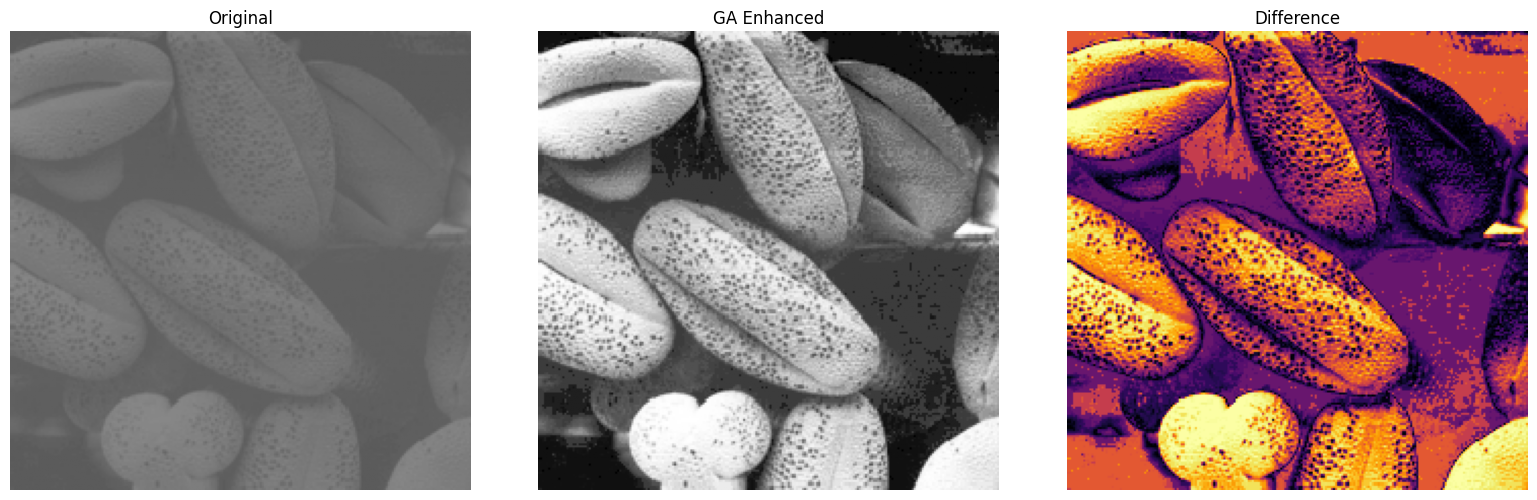

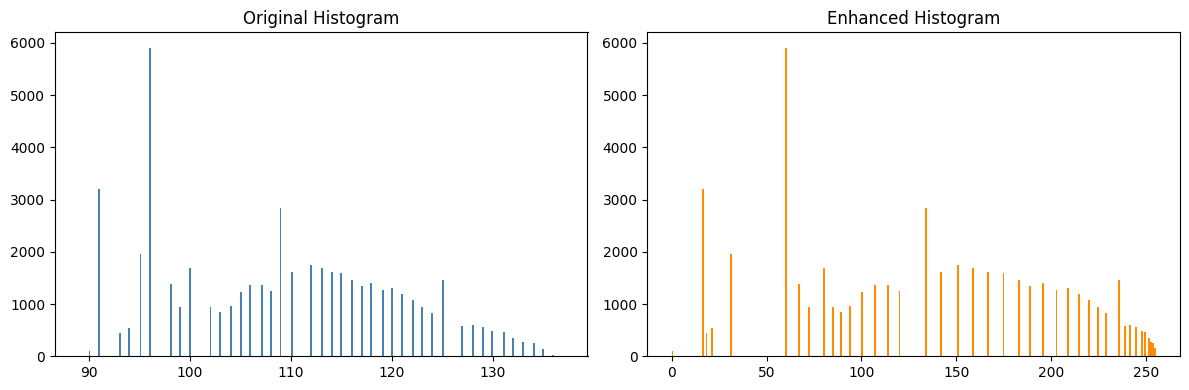

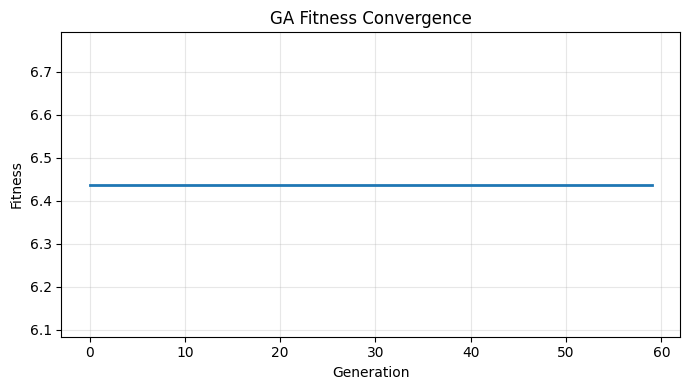

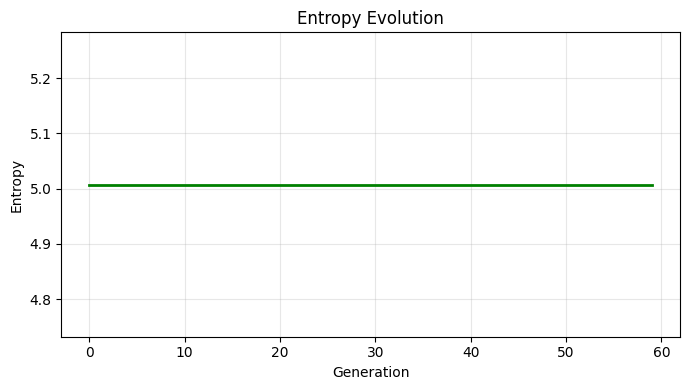

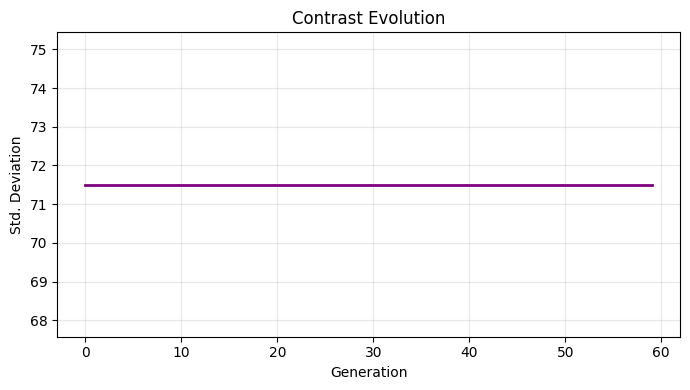

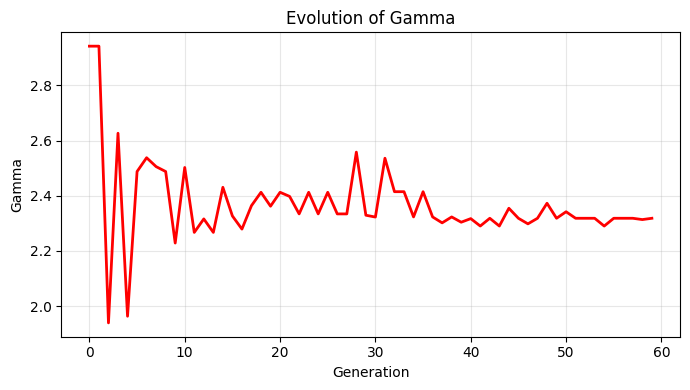

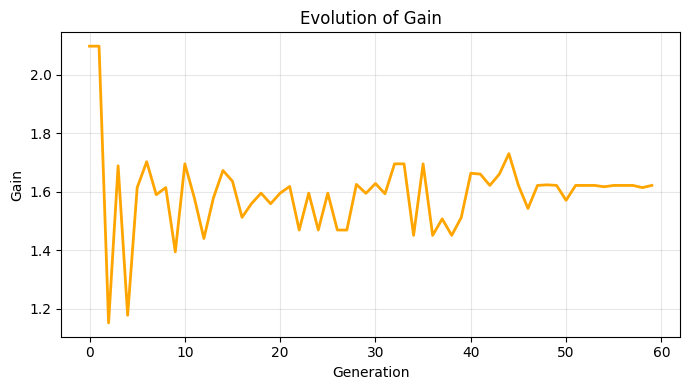

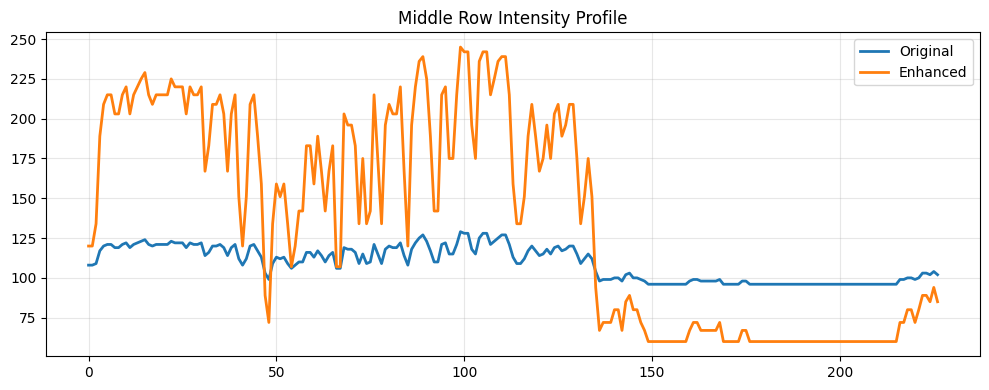

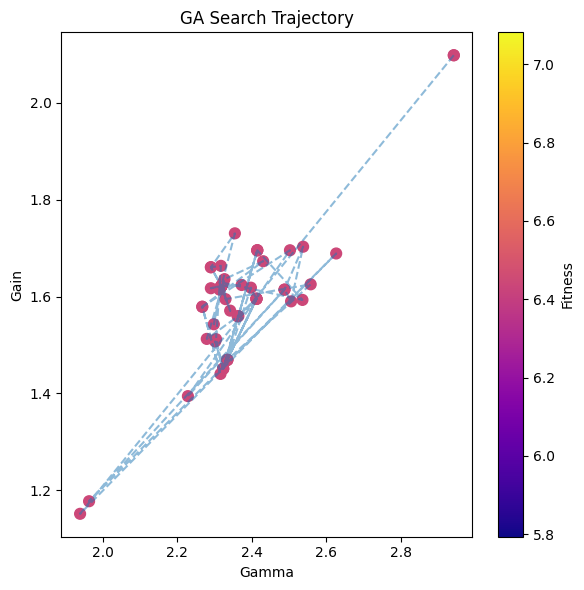

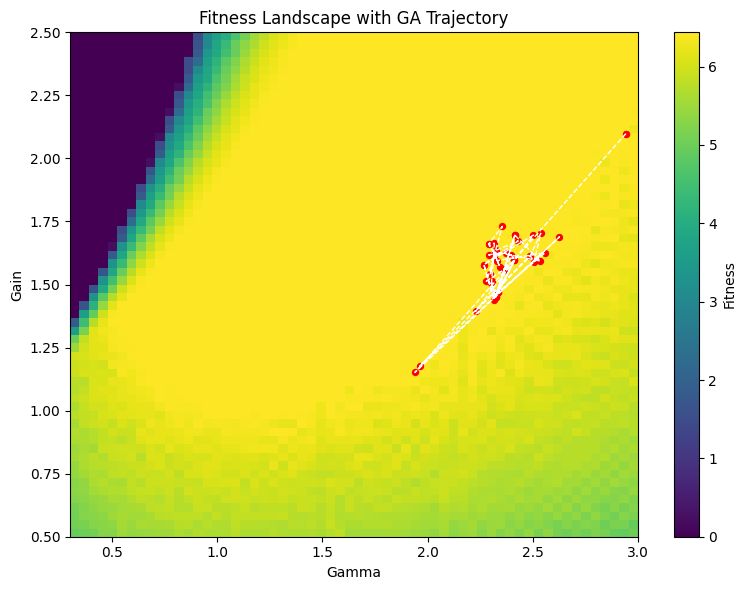

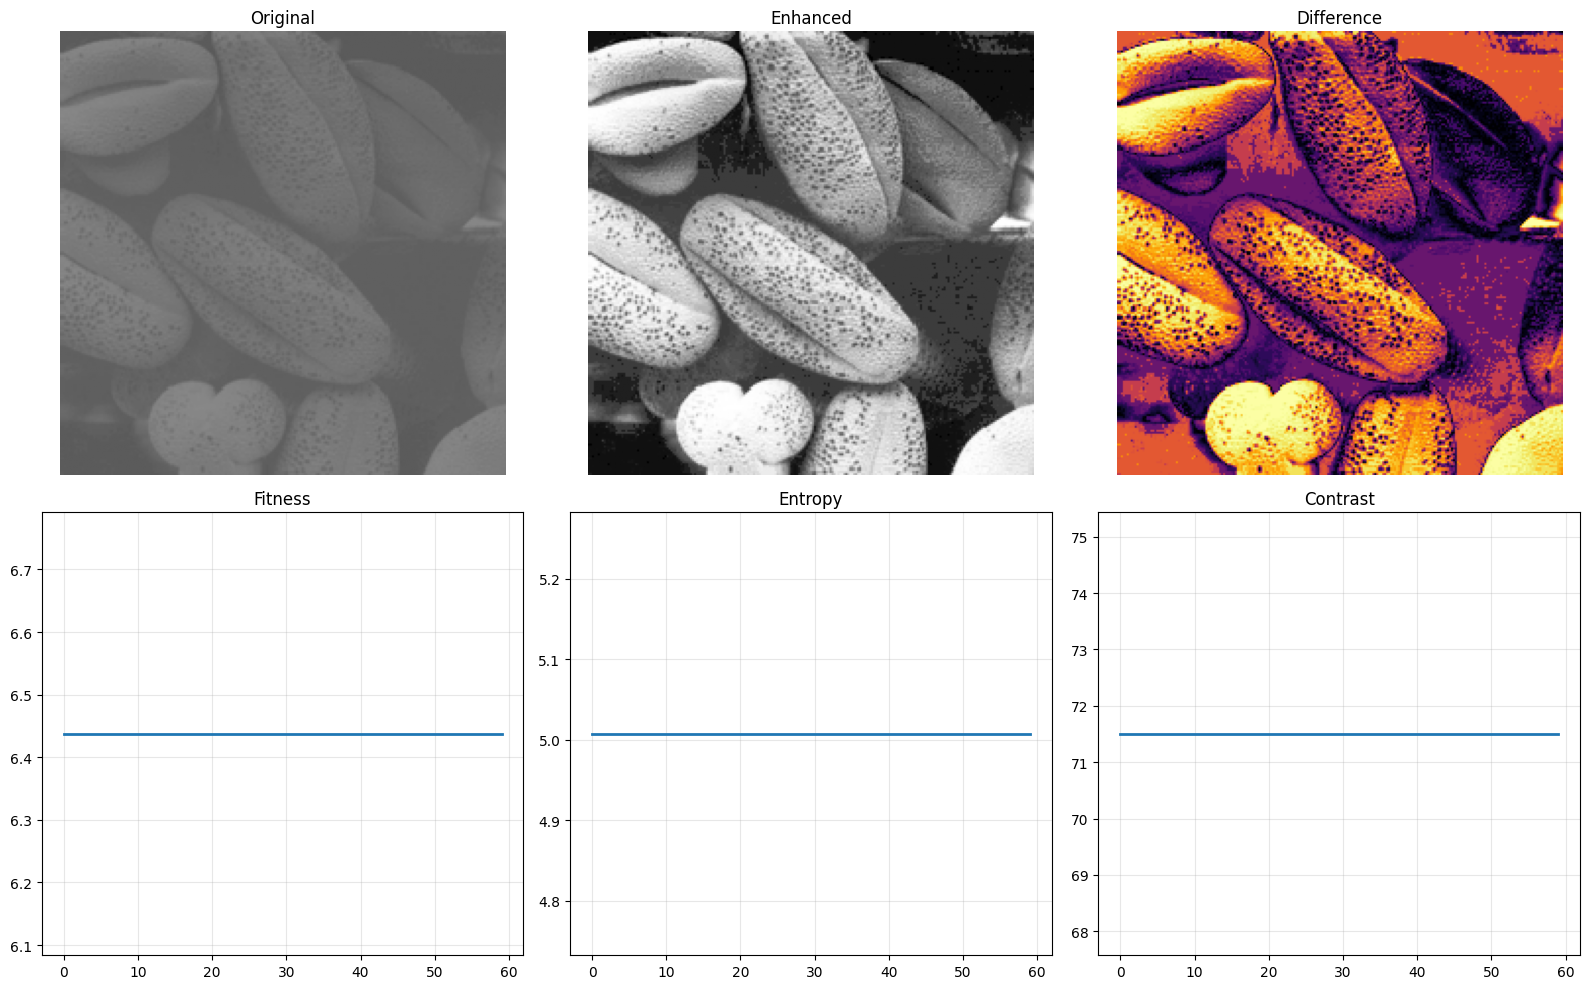

Genetic Algorithm Contrast Enhancement
Best Fitness : 6.4377
Best Gamma   : 2.9423
Best Gain    : 2.0983
Entropy      : 5.0076
Contrast     : 71.5066


In [7]:
# ============================================================
# Genetic Algorithm for Image Contrast Enhancement
# Initialization + GA Operators
# ============================================================

import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.measure import shannon_entropy

# ------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------
IMAGE_PATH = "images/beans.png"

POP_SIZE = 30
GENERATIONS = 60

CROSSOVER_RATE = 0.8
MUTATION_RATE = 0.25

ELITE = 2

np.random.seed(0)
random.seed(0)

# ------------------------------------------------------------
# LOAD IMAGE
# ------------------------------------------------------------
image = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)

if image is None:
    raise ValueError("Cannot load image.")

image = image.astype(np.uint8)

# ------------------------------------------------------------
# IMAGE ENHANCEMENT MODEL
#
# genome = [gamma, gain]
#
# gamma ∈ [0.3,3]
# gain  ∈ [0.5,2.5]
# ------------------------------------------------------------
def enhance(img, genome):

    gamma, gain = genome

    x = img.astype(np.float32) / 255.0

    x = gain * np.power(x, gamma)

    x = np.clip(x, 0, 1)

    x = (255 * x).astype(np.uint8)

    x = cv2.equalizeHist(x)

    return x


# ------------------------------------------------------------
# FITNESS
#
# maximize
#   entropy
#   contrast
#
# ------------------------------------------------------------
def fitness(genome):

    enhanced = enhance(image, genome)

    entropy = shannon_entropy(enhanced)

    contrast = enhanced.std()

    score = entropy + 0.02 * contrast

    return score


# ------------------------------------------------------------
# RANDOM GENOME
# ------------------------------------------------------------
def random_genome():

    gamma = np.random.uniform(0.3, 3.0)

    gain = np.random.uniform(0.5, 2.5)

    return np.array([gamma, gain], dtype=np.float32)


# ------------------------------------------------------------
# INITIAL POPULATION
# ------------------------------------------------------------
population = [random_genome() for _ in range(POP_SIZE)]


# ------------------------------------------------------------
# ROULETTE-WHEEL SELECTION
# ------------------------------------------------------------
def select(population, fitnesses):

    fitnesses = np.asarray(fitnesses)

    fitnesses -= fitnesses.min()

    fitnesses += 1e-8

    probs = fitnesses / fitnesses.sum()

    idx = np.random.choice(
        len(population),
        p=probs
    )

    return population[idx].copy()


# ------------------------------------------------------------
# BLEND CROSSOVER
# ------------------------------------------------------------
def crossover(parent1, parent2):

    if random.random() > CROSSOVER_RATE:
        return parent1.copy(), parent2.copy()
    alpha = np.random.rand()
    child1 = alpha * parent1 + (1 - alpha) * parent2
    child2 = alpha * parent2 + (1 - alpha) * parent1
    return child1, child2


# ------------------------------------------------------------
# MUTATION
# ------------------------------------------------------------
def mutate(child):

    child = child.copy()
    if random.random() < MUTATION_RATE:
        child[0] += np.random.normal(0, 0.15)
    if random.random() < MUTATION_RATE:
        child[1] += np.random.normal(0, 0.10)
    # parameter limits
    child[0] = np.clip(child[0], 0.3, 3.0)
    child[1] = np.clip(child[1], 0.5, 2.5)
    return child


# ------------------------------------------------------------
# HISTORY VARIABLES
# ------------------------------------------------------------
best_history = []
entropy_history = []
contrast_history = []
gamma_history = []
gain_history = []

print("Initialization complete.")
print(f"Population Size : {POP_SIZE}")
print(f"Generations     : {GENERATIONS}")


# ============================================================
# Evolution Loop + Best Solution
# ============================================================

print("\nStarting Genetic Algorithm...\n")

best_genome = None
best_score = -np.inf
best_image = None

for gen in range(GENERATIONS):

    # Evaluate population
    scores = np.array([fitness(g) for g in population])
    # Sort population (descending fitness)
    order = np.argsort(scores)[::-1]
    population = [population[i] for i in order]
    scores = scores[order]
    # Elitism
    new_population = []
    for i in range(ELITE):
        new_population.append(population[i].copy())
    # Best individual of this generation
    elite = population[0].copy()
    elite_score = scores[0]
    enhanced = enhance(image, elite)
    entropy = shannon_entropy(enhanced)
    contrast = enhanced.std()

    # Global best
    if elite_score > best_score:

        best_score = elite_score
        best_genome = elite.copy()
        best_image = enhanced.copy()

    # Store history
    best_history.append(elite_score)
    entropy_history.append(entropy)
    contrast_history.append(contrast)
    gamma_history.append(elite[0])
    gain_history.append(elite[1])

    # Print progress
    print(
        f"Generation {gen+1:03d}/{GENERATIONS} | "
        f"Fitness={elite_score:.4f} | "
        f"Entropy={entropy:.3f} | "
        f"Contrast={contrast:.2f} | "
        f"Gamma={elite[0]:.3f} | "
        f"Gain={elite[1]:.3f}"
    )

    # Reproduction
    while len(new_population) < POP_SIZE:

        p1 = select(population, scores)
        p2 = select(population, scores)
        child1, child2 = crossover(p1, p2)
        child1 = mutate(child1)
        child2 = mutate(child2)
        new_population.append(child1)
        if len(new_population) < POP_SIZE:
            new_population.append(child2)

    population = new_population

# FINAL RESULT
print("\nOptimization Finished")
print("-" * 55)
print(f"Best Fitness : {best_score:.4f}")
print(f"Best Gamma   : {best_genome[0]:.4f}")
print(f"Best Gain    : {best_genome[1]:.4f}")

# Recompute final image
best_image = enhance(image, best_genome)

# Visualizations
# Difference image
difference = cv2.absdiff(image, best_image)
# Original vs Enhanced vs Difference
fig, ax = plt.subplots(1,3, figsize=(16,5))
ax[0].imshow(image, vmin=0, vmax=255, cmap="gray")
ax[0].set_title("Original")
ax[0].axis("off")
ax[1].imshow(best_image, vmin=0, vmax=255, cmap="gray")
ax[1].set_title("GA Enhanced")
ax[1].axis("off")
ax[2].imshow(difference, cmap="inferno")
ax[2].set_title("Difference")
ax[2].axis("off")
plt.tight_layout()
plt.show()

# Histogram Comparison
fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].hist(image.ravel(), bins=256, color="steelblue")
ax[0].set_title("Original Histogram")
ax[1].hist(best_image.ravel(), bins=256, color="darkorange")
ax[1].set_title("Enhanced Histogram")
plt.tight_layout()
plt.show()

# Fitness Convergence
plt.figure(figsize=(7,4))
plt.plot(best_history, lw=2)
plt.grid(alpha=0.3)
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.title("GA Fitness Convergence")
plt.tight_layout()
plt.show()

# Entropy Evolution
plt.figure(figsize=(7,4))
plt.plot(entropy_history,
         lw=2,
         color="green")
plt.grid(alpha=0.3)
plt.xlabel("Generation")
plt.ylabel("Entropy")
plt.title("Entropy Evolution")
plt.tight_layout()
plt.show()

# Contrast Evolution
plt.figure(figsize=(7,4))
plt.plot(
    contrast_history,
    lw=2,
    color="purple"
)
plt.grid(alpha=0.3)
plt.xlabel("Generation")
plt.ylabel("Std. Deviation")
plt.title("Contrast Evolution")
plt.tight_layout()
plt.show()

# Gamma Evolution
plt.figure(figsize=(7,4))
plt.plot(
    gamma_history,
    lw=2,
    color="red"
)
plt.grid(alpha=0.3)
plt.xlabel("Generation")
plt.ylabel("Gamma")
plt.title("Evolution of Gamma")
plt.tight_layout()
plt.show()

# Gain Evolution
plt.figure(figsize=(7,4))
plt.plot(
    gain_history,
    lw=2,
    color="orange"
)
plt.grid(alpha=0.3)
plt.xlabel("Generation")
plt.ylabel("Gain")
plt.title("Evolution of Gain")
plt.tight_layout()
plt.show()

# Intensity Profile
row = image.shape[0] // 2
plt.figure(figsize=(10,4))
plt.plot(
    image[row],
    label="Original",
    lw=2
)
plt.plot(
    best_image[row],
    label="Enhanced",
    lw=2
)
plt.legend()
plt.title("Middle Row Intensity Profile")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Parameter Search Trajectory
plt.figure(figsize=(6,6))
sc = plt.scatter(
    gamma_history,
    gain_history,
    c=best_history,
    cmap="plasma",
    s=60
)
plt.plot(
    gamma_history,
    gain_history,
    "--",
    alpha=0.5
)
plt.xlabel("Gamma")
plt.ylabel("Gain")
plt.title("GA Search Trajectory")
plt.colorbar(sc, label="Fitness")
plt.tight_layout()
plt.show()

# Fitness Landscape
gammas = np.linspace(0.3,3.0,60)
gains = np.linspace(0.5,2.5,60)
Z = np.zeros((len(gains), len(gammas)))
for i,g in enumerate(gains):
    for j,gm in enumerate(gammas):
        Z[i,j] = fitness(np.array([gm,g]))

plt.figure(figsize=(8,6))
plt.imshow(
    Z,
    extent=[
        gammas.min(),
        gammas.max(),
        gains.min(),
        gains.max()
    ],
    origin="lower",
    aspect="auto",
    cmap="viridis"
)
plt.colorbar(label="Fitness")
plt.scatter(
    gamma_history,
    gain_history,
    c="red",
    s=18
)
plt.plot(
    gamma_history,
    gain_history,
    "w--",
    lw=1
)
plt.xlabel("Gamma")
plt.ylabel("Gain")
plt.title("Fitness Landscape with GA Trajectory")
plt.tight_layout()
plt.show()

# IEEE Summary Figure
fig, ax = plt.subplots(2,3, figsize=(16,10))
ax[0,0].imshow(image, vmin=0, vmax=255, cmap="gray")
ax[0,0].set_title("Original")
ax[0,0].axis("off")
ax[0,1].imshow(best_image, vmin=0, vmax=255, cmap="gray")
ax[0,1].set_title("Enhanced")
ax[0,1].axis("off")
ax[0,2].imshow(difference, cmap="inferno")
ax[0,2].set_title("Difference")
ax[0,2].axis("off")
ax[1,0].plot(best_history, lw=2)
ax[1,0].set_title("Fitness")
ax[1,1].plot(entropy_history, lw=2)
ax[1,1].set_title("Entropy")
ax[1,2].plot(contrast_history, lw=2)
ax[1,2].set_title("Contrast")
for a in ax[1]:
    a.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# FINAL REPORT
print("="*60)
print("Genetic Algorithm Contrast Enhancement")
print("="*60)
print(f"Best Fitness : {best_score:.4f}")
print(f"Best Gamma   : {best_genome[0]:.4f}")
print(f"Best Gain    : {best_genome[1]:.4f}")
print(f"Entropy      : {shannon_entropy(best_image):.4f}")
print(f"Contrast     : {best_image.std():.4f}")
print("="*60)

### **Image Contrast Enhancement: Genetic Algorithms versus Evolution Strategies**


Starting Evolution Strategy...

ES 001 Fitness=6.4374 Gamma=2.261 Gain=2.370
ES 002 Fitness=6.4374 Gamma=1.172 Gain=1.490
ES 003 Fitness=6.4374 Gamma=1.594 Gain=1.925
ES 004 Fitness=6.4374 Gamma=1.680 Gain=1.511
ES 005 Fitness=6.4377 Gamma=1.699 Gain=1.102
ES 006 Fitness=6.4377 Gamma=1.699 Gain=1.102
ES 007 Fitness=6.4377 Gamma=1.699 Gain=1.102
ES 008 Fitness=6.4377 Gamma=1.699 Gain=1.102
ES 009 Fitness=6.4377 Gamma=1.699 Gain=1.102
ES 010 Fitness=6.4377 Gamma=1.699 Gain=1.102
ES 011 Fitness=6.4377 Gamma=1.699 Gain=1.102
ES 012 Fitness=6.4377 Gamma=1.699 Gain=1.102
ES 013 Fitness=6.4377 Gamma=1.699 Gain=1.102
ES 014 Fitness=6.4377 Gamma=1.699 Gain=1.102
ES 015 Fitness=6.4377 Gamma=2.968 Gain=1.876
ES 016 Fitness=6.4377 Gamma=2.944 Gain=2.269
ES 017 Fitness=6.4377 Gamma=3.000 Gain=2.319
ES 018 Fitness=6.4377 Gamma=2.944 Gain=2.269
ES 019 Fitness=6.4377 Gamma=2.795 Gain=1.942
ES 020 Fitness=6.4377 Gamma=1.699 Gain=1.102
ES 021 Fitness=6.4377 Gamma=2.852 Gain=2.132
ES 022 Fitness=6.4377 

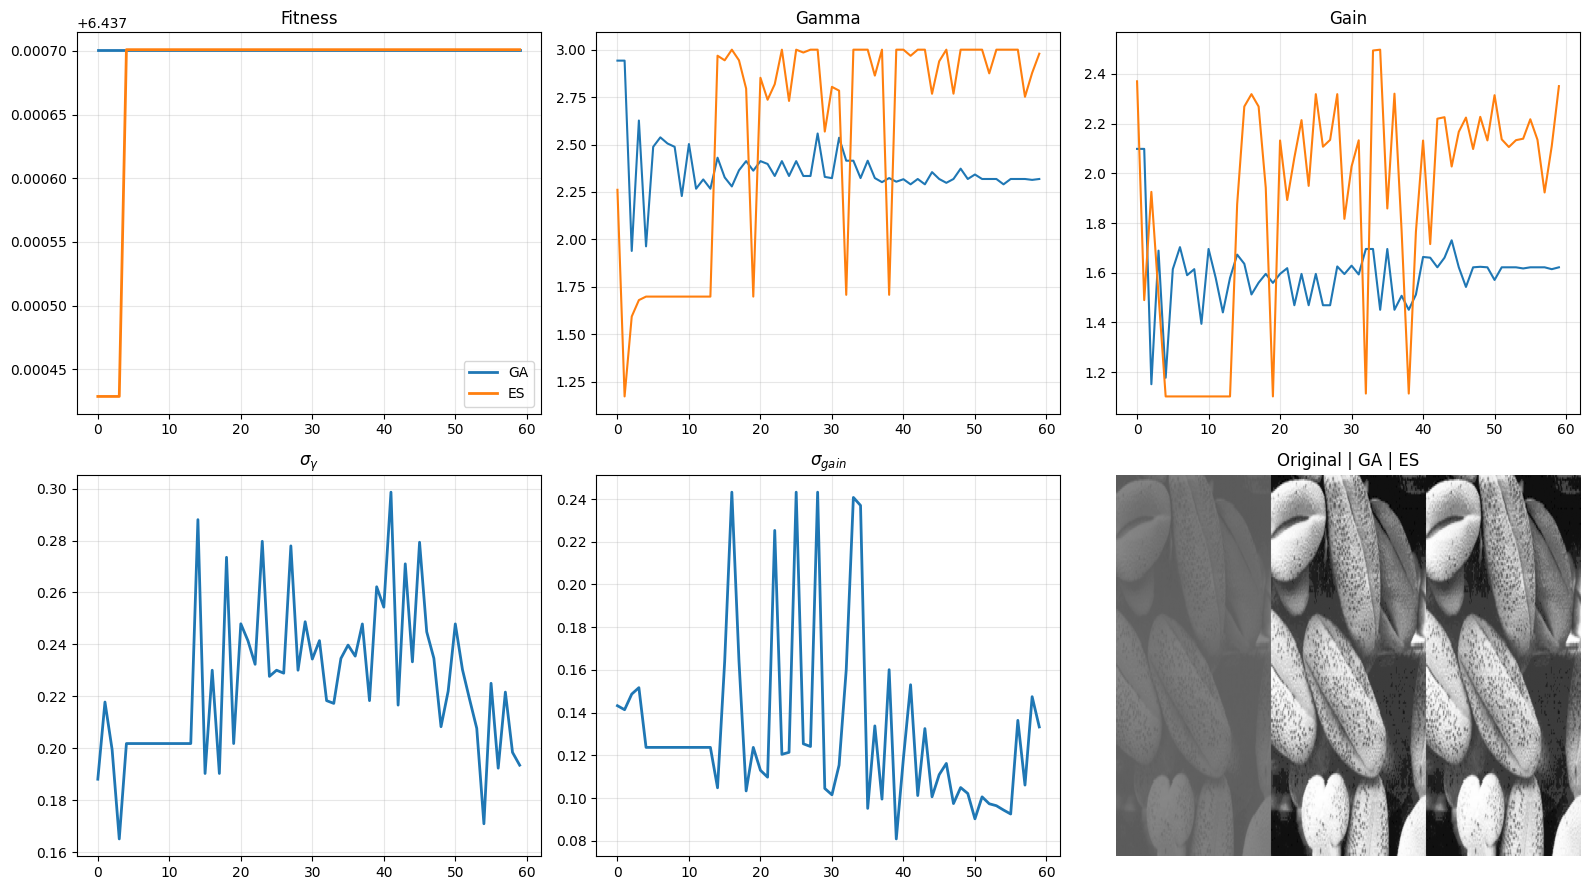

In [9]:
# ============================================================
# (μ + λ) Evolution Strategy
# ============================================================

MU = 10
LAMBDA = 40

# Individual:
# [gamma, gain, sigma_gamma, sigma_gain]

def random_individual():

    return np.array([
        np.random.uniform(0.3,3),
        np.random.uniform(0.5,2.5),
        0.20,
        0.15
    ])

population = [random_individual() for _ in range(MU)]

es_best_history = []
es_gamma_history = []
es_gain_history = []
sigma_gamma_history = []
sigma_gain_history = []

best_score_es = -np.inf

print("\nStarting Evolution Strategy...\n")

for gen in range(GENERATIONS):

    offspring = []

    # --------------------------------------------
    # Mutation only
    # --------------------------------------------
    for parent in population:

        for _ in range(LAMBDA // MU):

            child = parent.copy()

            # Self-adaptation
            child[2] *= np.exp(np.random.normal(0,0.08))
            child[3] *= np.exp(np.random.normal(0,0.08))

            child[0] += np.random.normal(0, child[2])
            child[1] += np.random.normal(0, child[3])

            child[0] = np.clip(child[0],0.3,3)
            child[1] = np.clip(child[1],0.5,2.5)

            offspring.append(child)

    # --------------------------------------------
    # Evaluate parents + offspring
    # --------------------------------------------
    combined = population + offspring

    scores = np.array([
        fitness(ind[:2])
        for ind in combined
    ])

    order = np.argsort(scores)[::-1]

    combined = [combined[i] for i in order]

    scores = scores[order]

    population = combined[:MU]

    best = population[0]

    score = scores[0]

    if score > best_score_es:

        best_score_es = score

        best_es = best.copy()

    es_best_history.append(score)

    es_gamma_history.append(best[0])

    es_gain_history.append(best[1])

    sigma_gamma_history.append(best[2])

    sigma_gain_history.append(best[3])

    print(
        f"ES {gen+1:03d} "
        f"Fitness={score:.4f} "
        f"Gamma={best[0]:.3f} "
        f"Gain={best[1]:.3f}"
    )

best_image_es = enhance(image,best_es[:2])

# ============================================================
# GA vs ES
# ============================================================

fig,ax = plt.subplots(2,3,figsize=(16,9))

# ------------------------------------------------------------
# Fitness
# ------------------------------------------------------------
ax[0,0].plot(best_history,label="GA",lw=2)

ax[0,0].plot(es_best_history,label="ES",lw=2)

ax[0,0].set_title("Fitness")

ax[0,0].legend()

ax[0,0].grid(alpha=.3)

# ------------------------------------------------------------
# Gamma
# ------------------------------------------------------------
ax[0,1].plot(gamma_history,label="GA")

ax[0,1].plot(es_gamma_history,label="ES")

ax[0,1].set_title("Gamma")

ax[0,1].grid(alpha=.3)

# ------------------------------------------------------------
# Gain
# ------------------------------------------------------------
ax[0,2].plot(gain_history,label="GA")

ax[0,2].plot(es_gain_history,label="ES")

ax[0,2].set_title("Gain")

ax[0,2].grid(alpha=.3)

# ------------------------------------------------------------
# Sigma evolution
# ------------------------------------------------------------
ax[1,0].plot(sigma_gamma_history,lw=2)

ax[1,0].set_title(r"$\sigma_\gamma$")

ax[1,0].grid(alpha=.3)

ax[1,1].plot(sigma_gain_history,lw=2)

ax[1,1].set_title(r"$\sigma_{gain}$")

ax[1,1].grid(alpha=.3)

# ------------------------------------------------------------
# Images
# ------------------------------------------------------------
comparison = np.hstack([
    image,
    best_image,
    best_image_es
])

ax[1,2].imshow(comparison,cmap="gray",vmin=0,vmax=255, aspect='auto')

ax[1,2].set_title("Original | GA | ES")

ax[1,2].axis("off")

plt.tight_layout()

plt.show()

### **Image Denoising with Genetic Algorithm**

Gen   0 | Fitness(energy) -0.03309 | True PSNR vs clean 27.56 dB | PSNR vs noisy 22.41 dB
Gen   1 | Fitness(energy) -0.03273 | True PSNR vs clean 27.57 dB | PSNR vs noisy 22.32 dB
Gen   2 | Fitness(energy) -0.03246 | True PSNR vs clean 27.59 dB | PSNR vs noisy 22.26 dB
Gen   3 | Fitness(energy) -0.03214 | True PSNR vs clean 27.60 dB | PSNR vs noisy 22.18 dB
Gen   4 | Fitness(energy) -0.03183 | True PSNR vs clean 27.62 dB | PSNR vs noisy 22.10 dB
Gen   5 | Fitness(energy) -0.03150 | True PSNR vs clean 27.63 dB | PSNR vs noisy 22.03 dB
Gen   6 | Fitness(energy) -0.03131 | True PSNR vs clean 27.64 dB | PSNR vs noisy 21.98 dB
Gen   7 | Fitness(energy) -0.03098 | True PSNR vs clean 27.65 dB | PSNR vs noisy 21.90 dB
Gen   8 | Fitness(energy) -0.03074 | True PSNR vs clean 27.66 dB | PSNR vs noisy 21.84 dB
Gen   9 | Fitness(energy) -0.03045 | True PSNR vs clean 27.67 dB | PSNR vs noisy 21.78 dB
Gen  10 | Fitness(energy) -0.03022 | True PSNR vs clean 27.68 dB | PSNR vs noisy 21.72 dB
Gen  11 | 

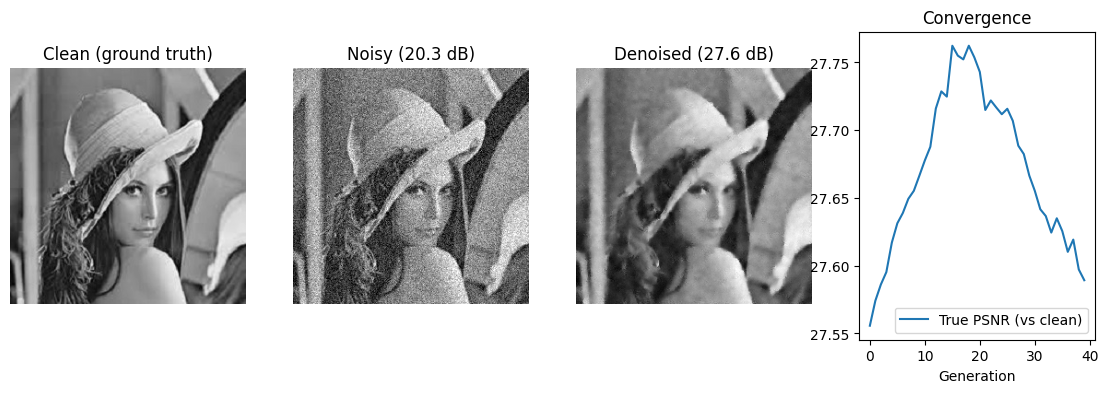

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
from skimage.metrics import structural_similarity as ssim

# =========================================================
# LOAD IMAGE
# =========================================================
img = cv2.imread("images/lena.jpg", cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError("Image not found")

img = img.astype(np.float32)

# Add synthetic noise
np.random.seed(0)
noisy_image = img + np.random.normal(0, 25, img.shape)
noisy_image = np.clip(noisy_image, 0, 255)

H, W = img.shape

# =========================================================
# PATCH SETTINGS
# =========================================================
PATCH_SIZE = 8
N_PATCHES = 50
POP_SIZE = 20
GENERATIONS = 40
MUTATION_RATE = 0.2
TOURNAMENT_K = 3

# LAMBDA_TV controls the fidelity-vs-smoothness tradeoff.
# Too low -> noise survives. Too high -> over-smoothed / blurry, loses detail.
# Tune this per noise level; 0.3-0.6 is a reasonable starting range for sigma=25.
LAMBDA_TV = 0.4

# =========================================================
# METRICS
# =========================================================
def psnr(a, b):
    mse = np.mean((a - b) ** 2)
    if mse == 0:
        return 100
    return 20 * np.log10(255.0 / np.sqrt(mse))

def tv(image):
    return np.mean(np.abs(np.diff(image, axis=0))) + np.mean(np.abs(np.diff(image, axis=1)))

# =========================================================
# FITNESS -- BLIND VARIATIONAL DENOISING ENERGY
# =========================================================
# CRITICAL FIX: this must NEVER reference the clean ground-truth `img`.
# Real denoising has no access to the clean image at inference time --
# a fitness that compares against `img` would trivially "solve" the
# problem by copying it, which isn't a real algorithm.
#
# Also critical: the OLD fitness rewarded similarity to the NOISY image,
# which directly rewards keeping noise. This is a proper ROF/TV-style
# energy instead: minimize (data fidelity to noisy) + lambda * (smoothness).
# Maximizing fitness = minimizing that energy.
def fitness(ind):
    ind = np.clip(ind, 0, 255).astype(np.float32)
    data_term = np.mean((ind - noisy_image) ** 2) / (255.0 ** 2)
    tv_term = tv(ind) / 255.0
    energy = data_term + LAMBDA_TV * tv_term
    return -energy

# =========================================================
# TRUE EVALUATION (ground truth -- for REPORTING ONLY, never for fitness)
# =========================================================
def true_psnr(ind):
    return psnr(img, ind)

def true_ssim(ind):
    return ssim(img, np.clip(ind, 0, 255).astype(np.float32), data_range=255.0)

# =========================================================
# INITIAL POPULATION
# =========================================================
# FIX: the old version ADDED extra noise on top of noisy_image, so the GA
# had to spend most of its budget just recovering back to the starting
# point. Instead, seed with a real classical denoiser (bilateral filter)
# at varying strengths -- this gives the GA a real head start, and the
# varying strengths give the population diversity to explore from.
def init_population():
    pop = []
    for i in range(POP_SIZE):
        d = np.random.uniform(0, 1)  # varying denoise strength per individual
        sigma_color = 10 + 40 * d
        sigma_space = 3 + 12 * d
        base = cv2.bilateralFilter(
            noisy_image.astype(np.float32), d=9,
            sigmaColor=sigma_color, sigmaSpace=sigma_space
        )
        pop.append(np.clip(base, 0, 255))
    return pop

# =========================================================
# PATCH MUTATION (LOCAL REFINEMENT)
# =========================================================
# FIX: old version only touched 5 random patches per call -- for a large
# image that's a tiny fraction of total patches, so most of the image
# never got refined across 40 generations. Sweep far more patches per
# mutation call so the whole image gets meaningfully touched.
N_MUTATION_PATCHES = 200  # was 5 -- raise/lower based on runtime budget

def mutate(ind):
    ind = ind.copy()
    for _ in range(N_MUTATION_PATCHES):
        if np.random.rand() < MUTATION_RATE:
            x = np.random.randint(0, H - PATCH_SIZE)
            y = np.random.randint(0, W - PATCH_SIZE)
            patch = ind[x:x+PATCH_SIZE, y:y+PATCH_SIZE]
            noise = np.random.normal(0, 6, patch.shape)      # smaller exploration noise
            smooth = cv2.GaussianBlur(patch, (3, 3), 0)
            patch = patch + 0.3 * noise + 0.7 * (smooth - patch)  # bias toward smoothing
            ind[x:x+PATCH_SIZE, y:y+PATCH_SIZE] = patch
    return np.clip(ind, 0, 255)

# =========================================================
# CROSSOVER (PATCH SWAP)
# =========================================================
def crossover(a, b):
    child = a.copy()
    for _ in range(5):
        x = np.random.randint(0, H - PATCH_SIZE)
        y = np.random.randint(0, W - PATCH_SIZE)
        if np.random.rand() < 0.5:
            child[x:x+PATCH_SIZE, y:y+PATCH_SIZE] = b[x:x+PATCH_SIZE, y:y+PATCH_SIZE]
    return child

# =========================================================
# SELECTION -- FIX: was uniform random, ignored fitness entirely
# =========================================================
def tournament_select(pop, scores):
    idx = np.random.choice(len(pop), TOURNAMENT_K, replace=False)
    best_idx = idx[np.argmax(scores[idx])]
    return pop[best_idx]

# =========================================================
# INIT
# =========================================================
population = init_population()

history_fitness = []
history_true_psnr = []   # what actually matters -- vs clean image

# =========================================================
# EVOLUTION LOOP
# =========================================================
for gen in range(GENERATIONS):

    scores = np.array([fitness(ind) for ind in population])
    idx = np.argmax(scores)
    best_ind = population[idx]

    history_fitness.append(scores[idx])
    history_true_psnr.append(true_psnr(best_ind))

    print(f"Gen {gen:3d} | Fitness(energy) {scores[idx]:.5f} | "
          f"True PSNR vs clean {history_true_psnr[-1]:.2f} dB | "
          f"PSNR vs noisy {psnr(noisy_image, best_ind):.2f} dB")

    elite = population[idx].copy()
    new_pop = [elite]

    while len(new_pop) < POP_SIZE:
        p1 = tournament_select(population, scores)
        p2 = tournament_select(population, scores)
        child = crossover(p1, p2)
        child = mutate(child)
        new_pop.append(child)

    population = new_pop

# =========================================================
# FINAL OUTPUT
# =========================================================
final_scores = [fitness(p) for p in population]
final_img = population[np.argmax(final_scores)]

print("\n===== FINAL REPORT =====")
print(f"Noisy input PSNR vs clean : {psnr(img, noisy_image):.2f} dB  (baseline, no denoising)")
print(f"GA result PSNR vs clean   : {true_psnr(final_img):.2f} dB")
print(f"GA result SSIM vs clean   : {true_ssim(final_img):.4f}")
print("========================")

plt.figure(figsize=(14, 4))

plt.subplot(1, 4, 1)
plt.imshow(img, cmap='gray')
plt.title(f"Clean (ground truth)")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(noisy_image, cmap='gray')
plt.title(f"Noisy ({psnr(img, noisy_image):.1f} dB)")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(final_img, cmap='gray')
plt.title(f"Denoised ({true_psnr(final_img):.1f} dB)")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.plot(history_true_psnr, label="True PSNR (vs clean)")
plt.legend()
plt.title("Convergence")
plt.xlabel("Generation")
plt.show()

### **Edge Detection with Ant Colony Optimization**

Iteration 01/40 | Mean=0.856 | Max=1.600
Iteration 02/40 | Mean=0.732 | Max=1.647
Iteration 03/40 | Mean=0.627 | Max=1.822
Iteration 04/40 | Mean=0.537 | Max=1.686
Iteration 05/40 | Mean=0.461 | Max=1.783
Iteration 06/40 | Mean=0.397 | Max=1.515
Iteration 07/40 | Mean=0.344 | Max=1.751
Iteration 08/40 | Mean=0.297 | Max=1.957
Iteration 09/40 | Mean=0.257 | Max=1.827
Iteration 10/40 | Mean=0.222 | Max=1.770
Iteration 11/40 | Mean=0.193 | Max=2.112
Iteration 12/40 | Mean=0.171 | Max=2.083
Iteration 13/40 | Mean=0.150 | Max=2.130
Iteration 14/40 | Mean=0.134 | Max=2.328
Iteration 15/40 | Mean=0.119 | Max=2.212
Iteration 16/40 | Mean=0.106 | Max=2.057
Iteration 17/40 | Mean=0.095 | Max=1.876
Iteration 18/40 | Mean=0.085 | Max=2.009
Iteration 19/40 | Mean=0.077 | Max=1.840
Iteration 20/40 | Mean=0.070 | Max=2.214
Iteration 21/40 | Mean=0.063 | Max=2.270
Iteration 22/40 | Mean=0.059 | Max=1.930
Iteration 23/40 | Mean=0.052 | Max=2.277
Iteration 24/40 | Mean=0.049 | Max=1.935
Iteration 25/40 

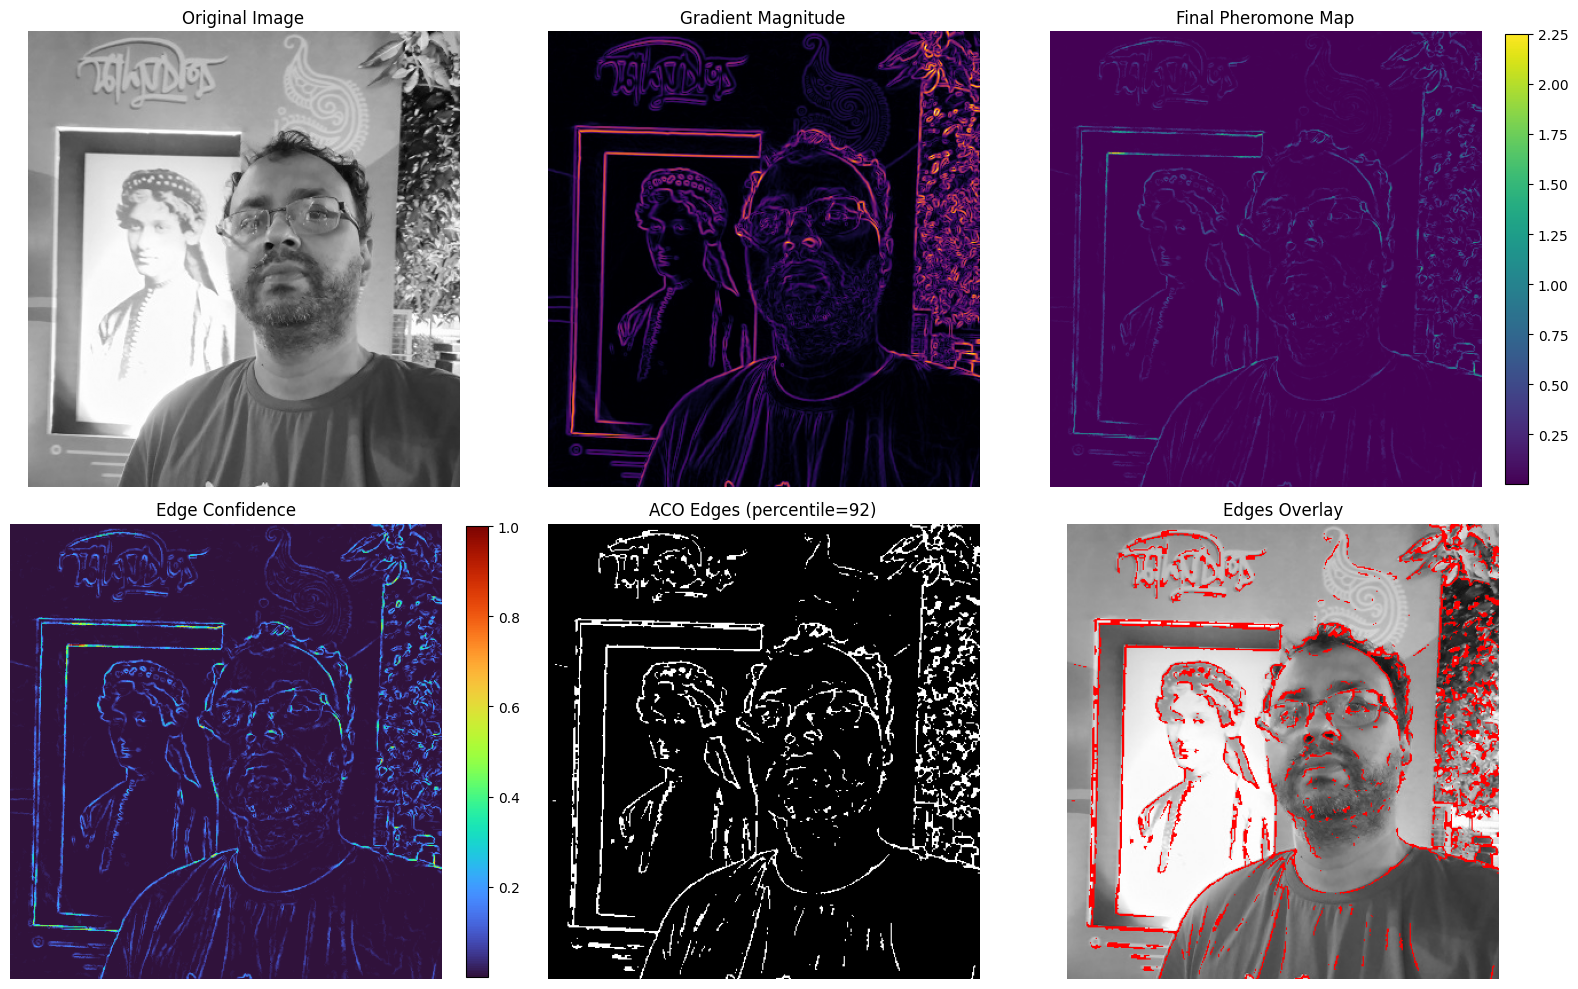

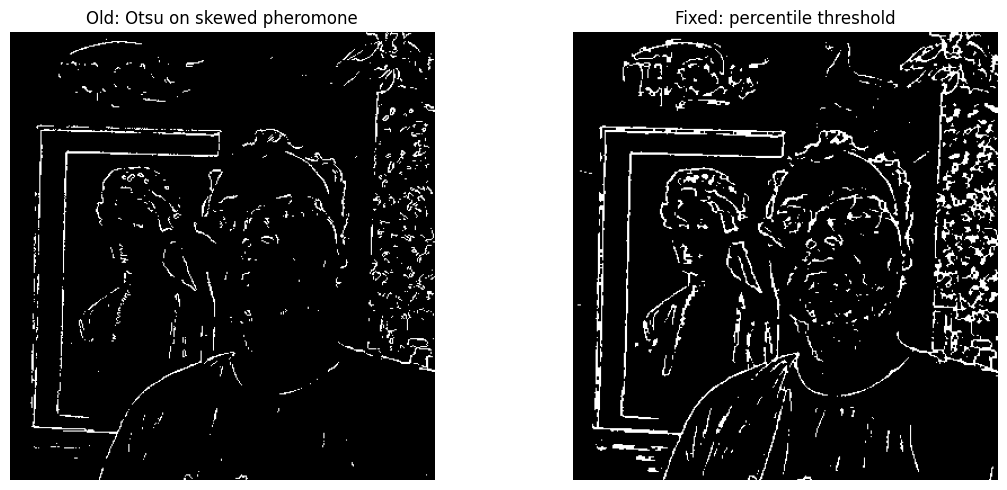

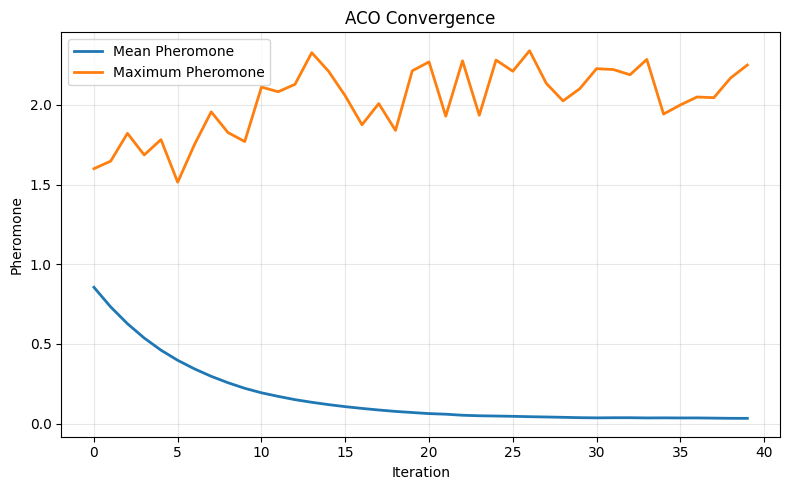

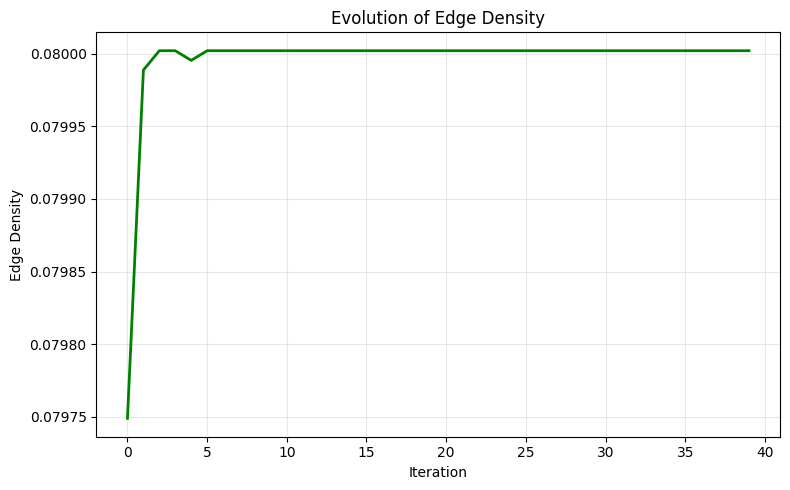

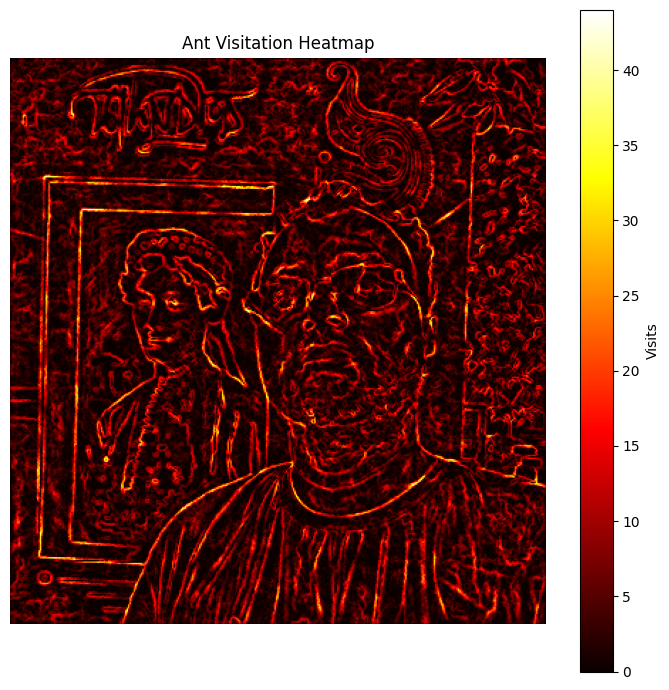

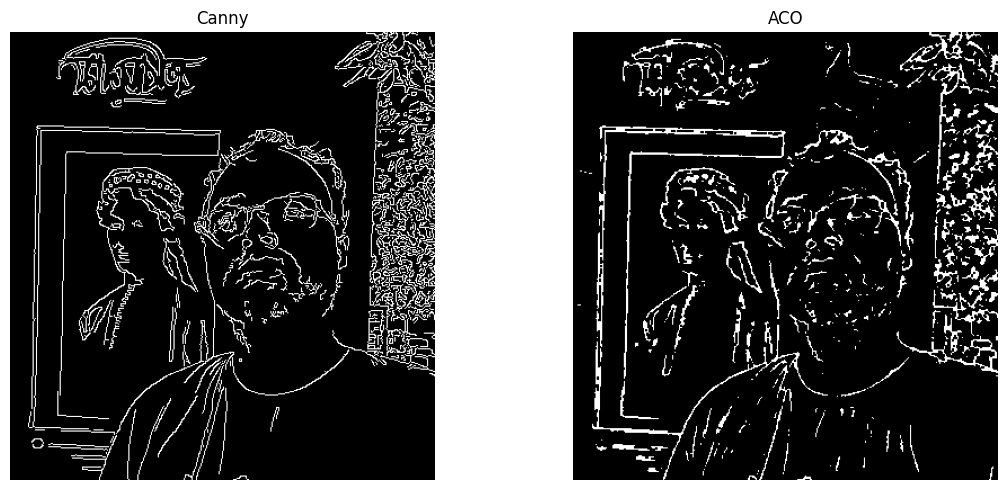


Finished.


In [15]:
# ==========================================================
# Ant Colony Optimization (ACO) for Edge Detection -- FIXED
# ==========================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# PARAMETERS
# ==========================================================
IMAGE_PATH = "images/me.jpg"

NUM_ANTS = 500
NUM_ITER = 40
STEPS = 30

ALPHA = 1.0          # pheromone importance
BETA = 2.0           # heuristic importance
RHO = 0.15           # evaporation -- raised from 0.08, helps counter runaway growth
Q = 5.0              # pheromone deposit

EDGE_PERCENTILE = 92  # final edge threshold: top (100-EDGE_PERCENTILE)% of pheromone

np.random.seed(0)

# ==========================================================
# LOAD IMAGE
# ==========================================================
img = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError("Cannot load image.")

img = img.astype(np.float32)
H, W = img.shape

# ==========================================================
# COMPUTE HEURISTIC (Gradient Magnitude)
# ==========================================================
gx = cv2.Sobel(img, cv2.CV_32F, 1, 0, ksize=3)
gy = cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=3)
grad = np.sqrt(gx**2 + gy**2)
grad /= grad.max() + 1e-8
heuristic = grad + 1e-6

# ==========================================================
# INITIAL PHEROMONE
# ==========================================================
pheromone = np.ones((H, W), dtype=np.float32)
visit_map = np.zeros((H, W), dtype=np.float32)

history_mean = []
history_max = []
edge_density = []

# 8-neighbour connectivity
moves = [
    (-1, -1), (-1, 0), (-1, 1),
    (0, -1),           (0, 1),
    (1, -1),  (1, 0),  (1, 1)
]

# ==========================================================
# MAIN ACO LOOP
# ==========================================================
for iteration in range(NUM_ITER):

    delta = np.zeros_like(pheromone)

    for ant in range(NUM_ANTS):

        x = np.random.randint(1, H - 1)
        y = np.random.randint(1, W - 1)

        # FIX: tabu set -- prevents an ant from oscillating back and forth
        # between the same couple of high-gradient neighbors, which is what
        # was causing pheromone to pile up on a tiny handful of pixels
        # instead of spreading along the actual edge contour.
        visited = {(x, y)}

        for step in range(STEPS):

            candidates = []
            weights = []

            for dx, dy in moves:
                nx, ny = x + dx, y + dy

                if 0 <= nx < H and 0 <= ny < W and (nx, ny) not in visited:
                    tau = pheromone[nx, ny] ** ALPHA
                    eta = heuristic[nx, ny] ** BETA
                    candidates.append((nx, ny))
                    weights.append(tau * eta)

            if not candidates:
                # ant is boxed in by its own tabu history -- release the
                # oldest constraint by allowing revisits, rather than
                # silently dying (which biases coverage toward whichever
                # spots ants got trapped near first)
                visited.clear()
                visited.add((x, y))
                continue

            weights = np.asarray(weights, dtype=np.float64)
            if weights.sum() == 0:
                break
            weights /= weights.sum()

            idx = np.random.choice(len(candidates), p=weights)
            x, y = candidates[idx]
            visited.add((x, y))

            visit_map[x, y] += 1
            delta[x, y] += Q * heuristic[x, y]

    # FIX: normalize the deposit before merging it in. Without this, a few
    # heavily-visited pixels accumulate pheromone that's orders of
    # magnitude larger than everywhere else, which later wrecks min-max
    # normalization and Otsu thresholding (crushes real edges to near-zero
    # contrast, leaves only extreme outliers above threshold).
    if delta.max() > 0:
        delta = delta / delta.max()

    pheromone = (1 - RHO) * pheromone + RHO * delta * (Q)

    history_mean.append(pheromone.mean())
    history_max.append(pheromone.max())

    threshold = np.percentile(pheromone, EDGE_PERCENTILE)
    edge_density.append(np.mean(pheromone > threshold))

    print(
        f"Iteration {iteration+1:02d}/{NUM_ITER} | "
        f"Mean={history_mean[-1]:.3f} | "
        f"Max={history_max[-1]:.3f}"
    )

print("\nACO optimization completed.")

# ==========================================================
# Part 2 : Post-processing + Visualizations
# ==========================================================

pheromone_norm = cv2.normalize(pheromone, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
confidence = pheromone / (pheromone.max() + 1e-8)

# FIX: percentile threshold instead of Otsu-on-skewed-data. Robust to the
# heavy-tailed pheromone distribution -- always keeps the top N% brightest
# pixels as edges, regardless of how extreme the outliers are.
edge_threshold = np.percentile(pheromone, EDGE_PERCENTILE)
edges = (pheromone > edge_threshold).astype(np.uint8) * 255

# light morphological closing to connect near-adjacent edge pixels into
# more continuous contours
edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, np.ones((2, 2), np.uint8))

# also compute the old Otsu result for direct comparison
_, edges_otsu = cv2.threshold(pheromone_norm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

overlay = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_GRAY2RGB)
overlay[edges > 0] = [255, 0, 0]

# ----------------------------------------------------------
# Figure 1 : Summary
# ----------------------------------------------------------
fig, ax = plt.subplots(2, 3, figsize=(16, 10))

ax[0, 0].imshow(img, cmap='gray'); ax[0, 0].set_title("Original Image"); ax[0, 0].axis("off")
ax[0, 1].imshow(grad, cmap='inferno'); ax[0, 1].set_title("Gradient Magnitude"); ax[0, 1].axis("off")

im = ax[0, 2].imshow(pheromone, cmap='viridis')
ax[0, 2].set_title("Final Pheromone Map"); ax[0, 2].axis("off")
plt.colorbar(im, ax=ax[0, 2], fraction=0.046)

im = ax[1, 0].imshow(confidence, cmap='turbo')
ax[1, 0].set_title("Edge Confidence"); ax[1, 0].axis("off")
plt.colorbar(im, ax=ax[1, 0], fraction=0.046)

ax[1, 1].imshow(edges, cmap='gray'); ax[1, 1].set_title(f"ACO Edges (percentile={EDGE_PERCENTILE})"); ax[1, 1].axis("off")
ax[1, 2].imshow(overlay); ax[1, 2].set_title("Edges Overlay"); ax[1, 2].axis("off")

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Figure 2 : Old Otsu approach vs fixed percentile approach
# ----------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(edges_otsu, cmap='gray'); ax[0].set_title("Old: Otsu on skewed pheromone"); ax[0].axis("off")
ax[1].imshow(edges, cmap='gray'); ax[1].set_title("Fixed: percentile threshold"); ax[1].axis("off")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Figure 3 : Convergence
# ----------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(history_mean, lw=2, label="Mean Pheromone")
plt.plot(history_max, lw=2, label="Maximum Pheromone")
plt.xlabel("Iteration"); plt.ylabel("Pheromone"); plt.title("ACO Convergence")
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

# ----------------------------------------------------------
# Figure 4 : Edge Density Evolution
# ----------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(edge_density, lw=2, color='green')
plt.xlabel("Iteration"); plt.ylabel("Edge Density"); plt.title("Evolution of Edge Density")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# ----------------------------------------------------------
# Figure 5 : Ant Visitation Heatmap
# ----------------------------------------------------------
plt.figure(figsize=(7, 7))
plt.imshow(visit_map, cmap="hot")
plt.colorbar(label="Visits")
plt.title("Ant Visitation Heatmap")
plt.axis("off"); plt.tight_layout(); plt.show()

# ----------------------------------------------------------
# Figure 6 : Comparison with Canny
# ----------------------------------------------------------
canny = cv2.Canny(img.astype(np.uint8), 100, 200)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(canny, cmap='gray'); ax[0].set_title("Canny"); ax[0].axis("off")
ax[1].imshow(edges, cmap='gray'); ax[1].set_title("ACO"); ax[1].axis("off")
plt.tight_layout()
plt.show()

print("\nFinished.")

### **Multilevel segmentation with Genetic Algorithm**

Best thresholds: [65, 105, 154]
saved demo2
saved demo2 convergence


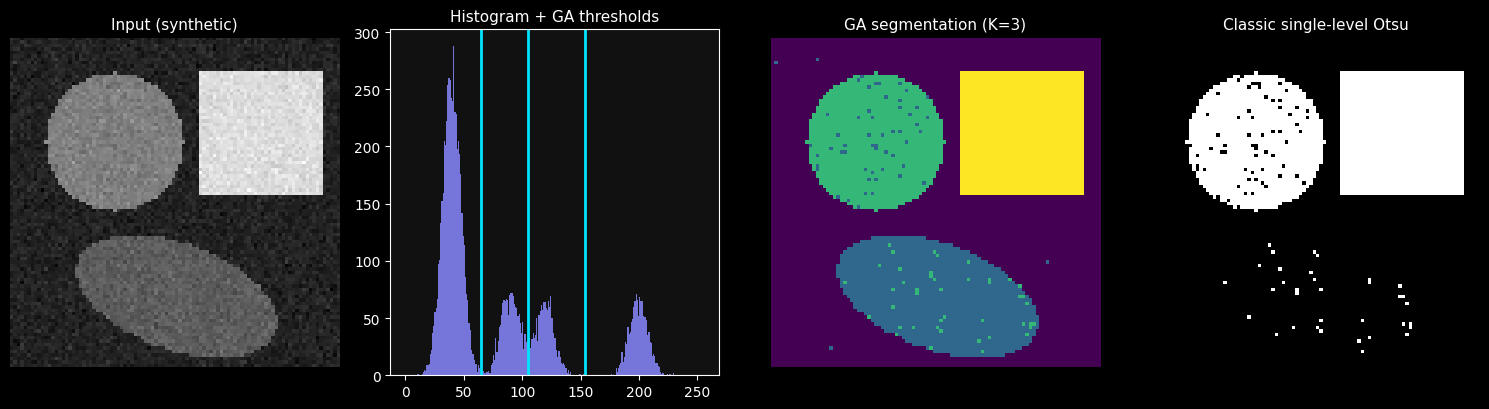

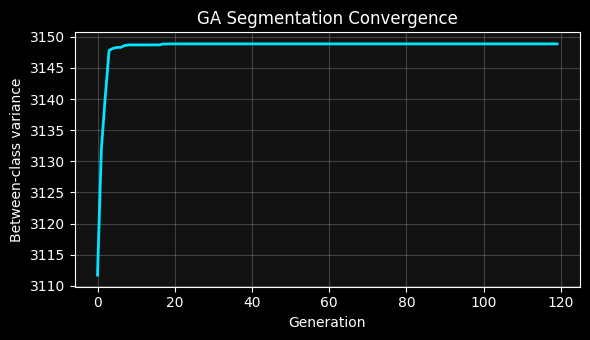

In [18]:
"""
Genetic Algorithm for multilevel image segmentation.
Searches for the set of K threshold values that maximizes Otsu's
between-class variance criterion -- classic GA-optimized segmentation.
"""
import cv2
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(3)

SIZE = 96
K = 3               # number of thresholds -> K+1 segments
POP_SIZE = 30
GENERATIONS = 120
ELITISM = 3
MUTATION_RATE = 0.3

# ---- synthetic multi-region grayscale image ----
img = np.zeros((SIZE, SIZE), dtype=np.float32)
img[:, :] = 40
cv2.circle(img, (30, 30), 20, 120, -1)
cv2.rectangle(img, (55, 10), (90, 45), 200, -1)
cv2.ellipse(img, (48, 75), (30, 15), 20, 0, 360, 90, -1)
img += np.random.normal(0, 8, img.shape)
img = np.clip(img, 0, 255)

hist, _ = np.histogram(img.ravel(), bins=256, range=(0, 256))
hist = hist.astype(np.float64) / hist.sum()
levels = np.arange(256)


def between_class_variance(thresholds):
    thr = sorted(int(np.clip(t, 1, 254)) for t in thresholds)
    bounds = [0] + thr + [256]
    global_mean = np.sum(levels * hist)
    variance = 0.0
    for lo, hi in zip(bounds[:-1], bounds[1:]):
        w = hist[lo:hi].sum()
        if w <= 1e-8:
            continue
        mean = np.sum(levels[lo:hi] * hist[lo:hi]) / w
        variance += w * (mean - global_mean) ** 2
    return variance


def fitness(ind):
    return between_class_variance(ind)  # maximize


def random_individual():
    return np.sort(np.random.randint(1, 255, K)).astype(np.float32)


def tournament_select(pop, scores, k=4):
    idx = np.random.choice(len(pop), k, replace=False)
    return pop[idx[np.argmax(scores[idx])]]


def crossover(p1, p2):
    point = np.random.randint(1, K) if K > 1 else 1
    child = np.concatenate([p1[:point], p2[point:]])
    return child.copy()


def mutate(ind):
    ind = ind.copy()
    mask = np.random.rand(K) < MUTATION_RATE
    ind[mask] += np.random.normal(0, 15, mask.sum())
    return np.clip(ind, 1, 254)


population = [random_individual() for _ in range(POP_SIZE)]
history = []

for gen in range(GENERATIONS):
    scores = np.array([fitness(ind) for ind in population])
    order = np.argsort(-scores)
    population = [population[i] for i in order]
    scores = scores[order]
    history.append(scores[0])

    new_pop = population[:ELITISM]
    while len(new_pop) < POP_SIZE:
        p1 = tournament_select(population, scores)
        p2 = tournament_select(population, scores)
        new_pop.append(mutate(crossover(p1, p2)))
    population = new_pop

best_thresholds = sorted(int(t) for t in population[0])
print("Best thresholds:", best_thresholds)

bounds = [0] + best_thresholds + [256]
segmented = np.zeros_like(img)
palette = np.linspace(30, 255, K + 1)
for (lo, hi), val in zip(zip(bounds[:-1], bounds[1:]), palette):
    segmented[(img >= lo) & (img < hi)] = val

# also run classic single-threshold Otsu for comparison
otsu_val, otsu_img = cv2.threshold(img.astype(np.uint8), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# ---- fancy visualization ----
plt.style.use("dark_background")
fig, ax = plt.subplots(1, 4, figsize=(15, 4.2))

ax[0].imshow(img, cmap="gray"); ax[0].set_title("Input (synthetic)", fontsize=11); ax[0].axis("off")

ax[1].hist(img.ravel(), bins=256, range=(0, 256), color="#8888ff", alpha=0.85)
for t in best_thresholds:
    ax[1].axvline(t, color="#00e5ff", lw=2)
ax[1].set_title("Histogram + GA thresholds", fontsize=11)
ax[1].set_facecolor("#111111")

ax[2].imshow(segmented, cmap="viridis"); ax[2].set_title(f"GA segmentation (K={K})", fontsize=11); ax[2].axis("off")
ax[3].imshow(otsu_img, cmap="gray"); ax[3].set_title("Classic single-level Otsu", fontsize=11); ax[3].axis("off")

plt.tight_layout()
plt.savefig("images/out_segmentation.png", dpi=140, facecolor="#0a0a0a")
print("saved demo2")

plt.figure(figsize=(6, 3.5))
plt.plot(history, color="#00e5ff", lw=2)
plt.xlabel("Generation"); plt.ylabel("Between-class variance")
plt.title("GA Segmentation Convergence")
plt.gca().set_facecolor("#111111")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("images/out_seg_convergence.png", dpi=140, facecolor="#0a0a0a")
print("saved demo2 convergence")

### **Feature Selection Using Binary Particle Swarm Optimization**

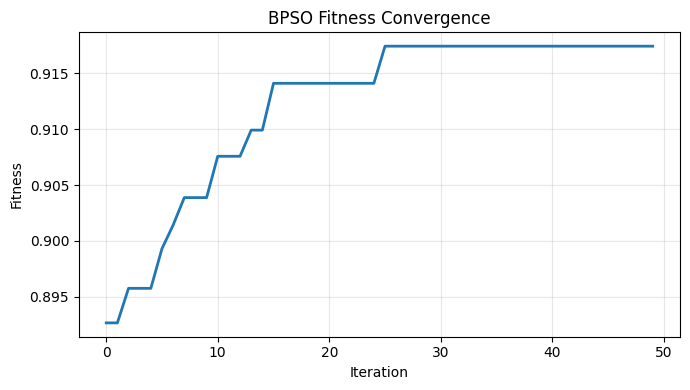

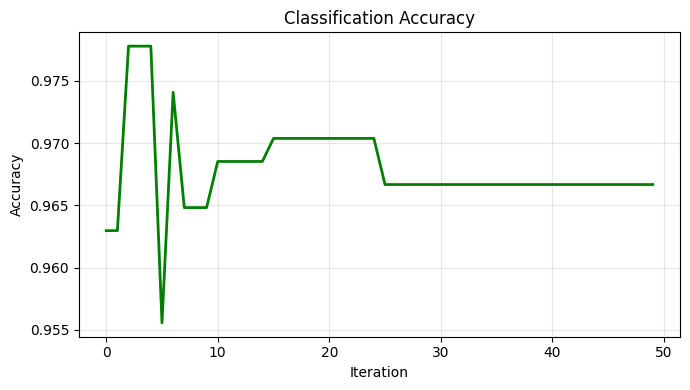

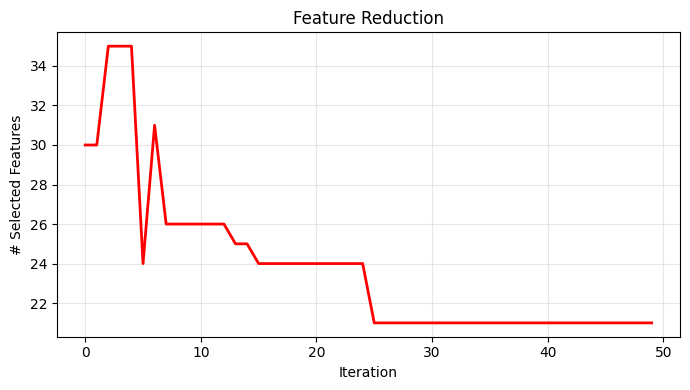

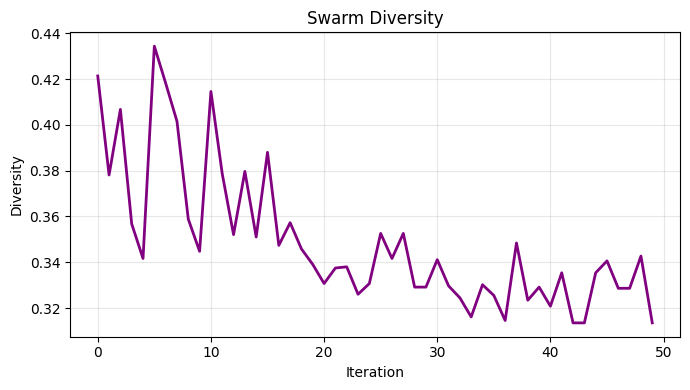

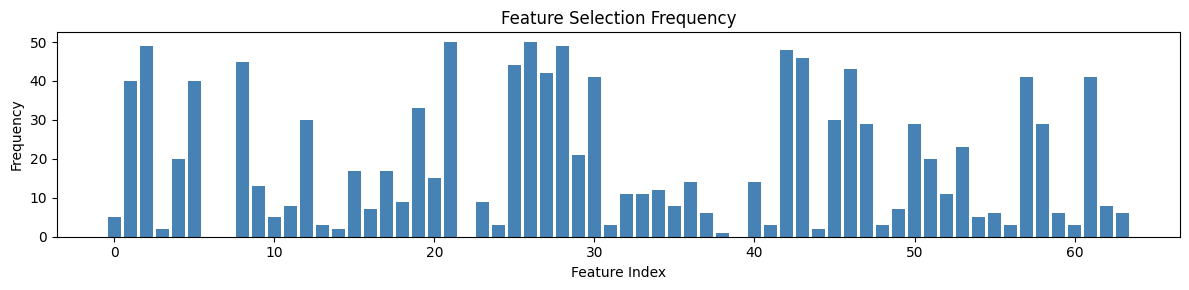

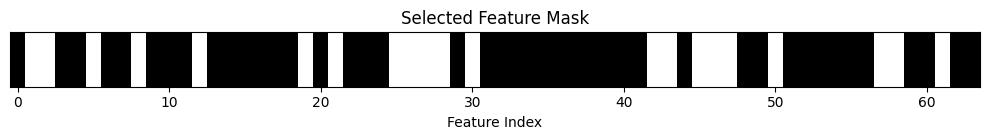

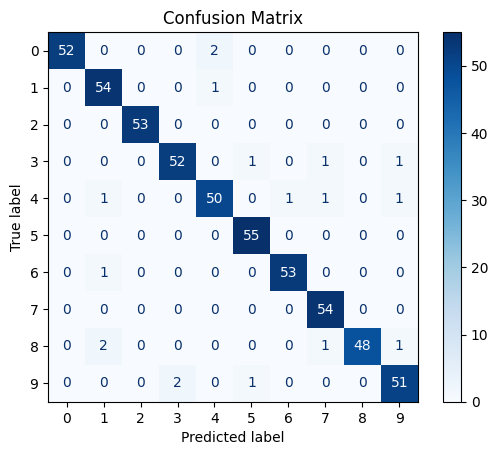

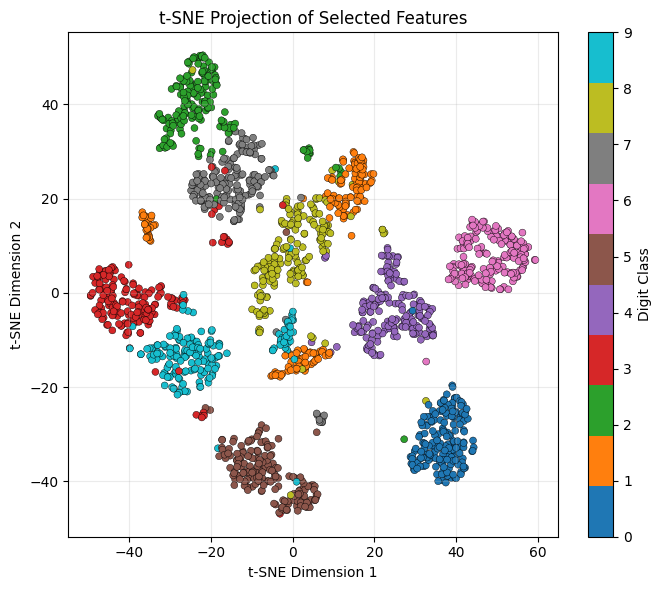

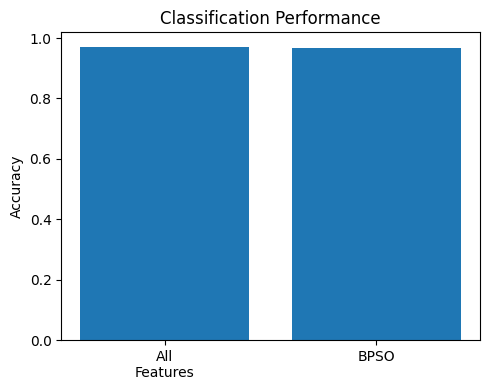

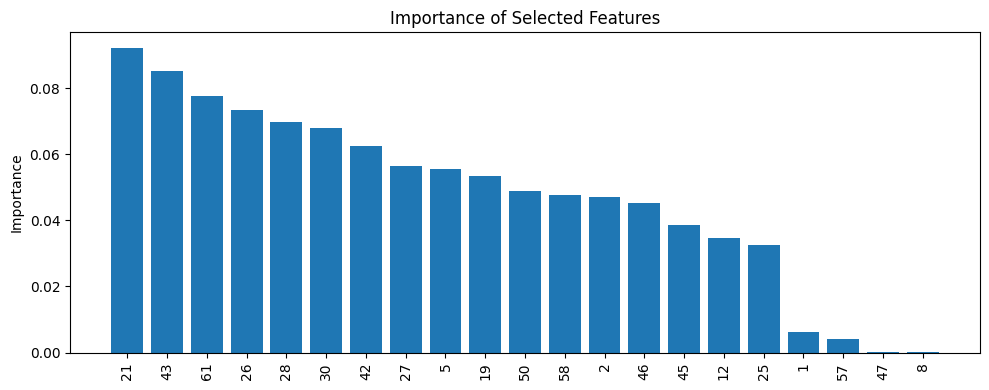

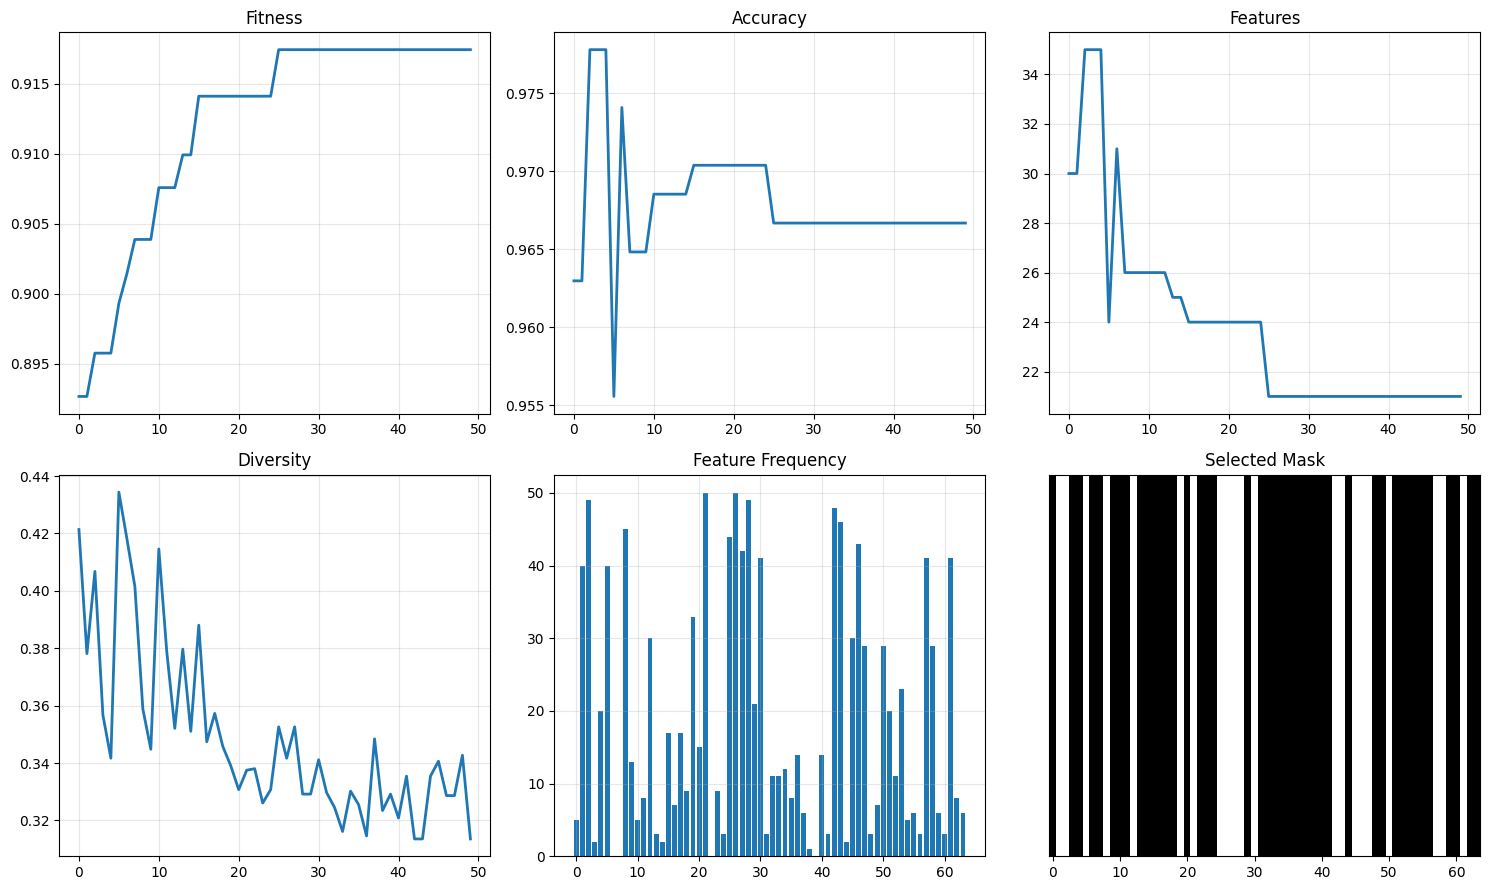

Binary Particle Swarm Optimization for Feature Selection
Original Features : 64
Selected Features : 21
Reduction         : 67.2%
Baseline Accuracy : 0.9704
BPSO Accuracy     : 0.9667
Best Fitness      : 0.9174


In [4]:
# ============================================================
# Binary Particle Swarm Optimization (BPSO)
# for Feature Selection
#
# Data + BPSO Initialization
# ============================================================

import random
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ------------------------------------------------------------
# RANDOM SEED
# ------------------------------------------------------------
np.random.seed(0)
random.seed(0)

# ============================================================
# LOAD DATASET
# ============================================================
digits = load_digits()

X = digits.data          # (1797,64)
y = digits.target

n_features = X.shape[1]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=0,
    stratify=y
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])
print("Number of Features :", n_features)

# ============================================================
# BPSO PARAMETERS
# ============================================================
NUM_PARTICLES = 30
MAX_ITER = 50

W = 0.72
C1 = 1.49
C2 = 1.49

# ============================================================
# SIGMOID TRANSFER FUNCTION
# ============================================================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

# ============================================================
# PARTICLE
# ============================================================
class Particle:

    def __init__(self):

        # Binary position
        self.position = np.random.randint(
            0,
            2,
            n_features
        ).astype(np.int32)

        # Ensure at least one feature
        if self.position.sum() == 0:
            self.position[np.random.randint(n_features)] = 1

        # Continuous velocity
        self.velocity = np.random.uniform(
            -1,
            1,
            n_features
        )

        self.best_position = self.position.copy()
        self.best_score = -np.inf

# ============================================================
# FITNESS
#
# Maximize:
#
# Accuracy
#
# Minimize:
#
# Number of features
# ============================================================
def fitness(mask):

    if mask.sum() == 0:
        return 0.0

    Xtr = X_train[:, mask == 1]
    Xte = X_test[:, mask == 1]

    clf = RandomForestClassifier(
        n_estimators=100,
        random_state=0,
        n_jobs=-1
    )

    clf.fit(Xtr, y_train)

    pred = clf.predict(Xte)

    acc = accuracy_score(y_test, pred)

    penalty = mask.sum() / n_features

    score = acc - 0.15 * penalty

    return score

# ============================================================
# INITIALIZE SWARM
# ============================================================
swarm = [
    Particle()
    for _ in range(NUM_PARTICLES)
]

global_best = None
global_best_score = -np.inf

# ============================================================
# HISTORY
# ============================================================
fitness_history = []

accuracy_history = []

feature_history = []

diversity_history = []

selection_frequency = np.zeros(
    n_features,
    dtype=np.int32
)

print("\nInitialization complete.")

# ============================================================
# Binary PSO Optimization
# ============================================================

print("\nStarting Binary PSO...\n")

for iteration in range(MAX_ITER):

    # --------------------------------------------------------
    # Evaluate particles
    # --------------------------------------------------------
    for particle in swarm:

        score = fitness(particle.position)

        # Personal best
        if score > particle.best_score:
            particle.best_score = score
            particle.best_position = particle.position.copy()

        # Global best
        if score > global_best_score:
            global_best_score = score
            global_best = particle.position.copy()

    # --------------------------------------------------------
    # Update particles
    # --------------------------------------------------------
    for particle in swarm:

        r1 = np.random.rand(n_features)
        r2 = np.random.rand(n_features)

        particle.velocity = (
            W * particle.velocity
            + C1 * r1 * (particle.best_position - particle.position)
            + C2 * r2 * (global_best - particle.position)
        )

        prob = sigmoid(particle.velocity)

        particle.position = (
            np.random.rand(n_features) < prob
        ).astype(np.int32)

        # Ensure at least one feature
        if particle.position.sum() == 0:
            particle.position[np.random.randint(n_features)] = 1

    # --------------------------------------------------------
    # Evaluate global best classifier
    # --------------------------------------------------------
    Xtr = X_train[:, global_best == 1]
    Xte = X_test[:, global_best == 1]

    clf = RandomForestClassifier(
        n_estimators=100,
        random_state=0,
        n_jobs=-1
    )

    clf.fit(Xtr, y_train)

    pred = clf.predict(Xte)

    acc = accuracy_score(y_test, pred)

    # --------------------------------------------------------
    # Statistics
    # --------------------------------------------------------
    fitness_history.append(global_best_score)
    accuracy_history.append(acc)
    feature_history.append(global_best.sum())

    # Swarm diversity
    diversity = np.mean([
        np.mean(p.position != global_best)
        for p in swarm
    ])

    diversity_history.append(diversity)

    # Feature frequency
    selection_frequency += global_best

    print(
        f"Iteration {iteration+1:02d}/{MAX_ITER} | "
        f"Fitness={global_best_score:.4f} | "
        f"Accuracy={acc:.4f} | "
        f"Features={global_best.sum()}"
    )

# ============================================================
# FINAL MODEL
# ============================================================

selected_features = np.where(global_best == 1)[0]

Xtr = X_train[:, selected_features]
Xte = X_test[:, selected_features]

final_model = RandomForestClassifier(
    n_estimators=100,
    random_state=0,
    n_jobs=-1
)

final_model.fit(Xtr, y_train)

pred = final_model.predict(Xte)

final_accuracy = accuracy_score(y_test, pred)

print("\nOptimization Finished")
print("-" * 60)
print("Selected Features :", len(selected_features))
print("Feature Indices   :", selected_features)
print(f"Final Accuracy    : {final_accuracy:.4f}")
print(f"Best Fitness      : {global_best_score:.4f}")
print("-" * 60)

# ============================================================
# Publication-Quality Visualizations
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

# ============================================================
# Figure 1 : Fitness Convergence
# ============================================================
plt.figure(figsize=(7,4))

plt.plot(
    fitness_history,
    lw=2
)

plt.grid(alpha=0.3)

plt.xlabel("Iteration")
plt.ylabel("Fitness")

plt.title("BPSO Fitness Convergence")

plt.tight_layout()
plt.show()

# ============================================================
# Figure 2 : Classification Accuracy
# ============================================================
plt.figure(figsize=(7,4))

plt.plot(
    accuracy_history,
    lw=2,
    color="green"
)

plt.grid(alpha=0.3)

plt.xlabel("Iteration")
plt.ylabel("Accuracy")

plt.title("Classification Accuracy")

plt.tight_layout()
plt.show()

# ============================================================
# Figure 3 : Number of Selected Features
# ============================================================
plt.figure(figsize=(7,4))

plt.plot(
    feature_history,
    lw=2,
    color="red"
)

plt.grid(alpha=0.3)

plt.xlabel("Iteration")
plt.ylabel("# Selected Features")

plt.title("Feature Reduction")

plt.tight_layout()
plt.show()

# ============================================================
# Figure 4 : Swarm Diversity
# ============================================================
plt.figure(figsize=(7,4))

plt.plot(
    diversity_history,
    lw=2,
    color="purple"
)

plt.grid(alpha=0.3)

plt.xlabel("Iteration")
plt.ylabel("Diversity")

plt.title("Swarm Diversity")

plt.tight_layout()
plt.show()

# ============================================================
# Figure 5 : Feature Selection Frequency
# ============================================================
plt.figure(figsize=(12,3))

plt.bar(
    np.arange(n_features),
    selection_frequency,
    color="steelblue"
)

plt.xlabel("Feature Index")
plt.ylabel("Frequency")

plt.title("Feature Selection Frequency")

plt.tight_layout()
plt.show()

# ============================================================
# Figure 6 : Selected Feature Mask
# ============================================================
plt.figure(figsize=(10,1.5))

plt.imshow(
    global_best.reshape(1,-1),
    cmap="gray",
    aspect="auto"
)

plt.yticks([])
plt.xlabel("Feature Index")

plt.title("Selected Feature Mask")

plt.tight_layout()
plt.show()

# ============================================================
# Figure 7 : Confusion Matrix
# ============================================================
cm = confusion_matrix(
    y_test,
    pred
)

disp = ConfusionMatrixDisplay(cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

# ============================================================
# Figure 8 : t-SNE Projection
# ============================================================
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=0
)

X_proj = tsne.fit_transform(
    X[:, selected_features]
)

plt.figure(figsize=(7,6))

scatter = plt.scatter(
    X_proj[:,0],
    X_proj[:,1],
    c=y,
    cmap="tab10",
    s=25,
    edgecolors="k",
    linewidths=0.3
)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

plt.title("t-SNE Projection of Selected Features")

plt.colorbar(scatter, label="Digit Class")

plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()
# ============================================================
# Figure 9 : Before vs After
# ============================================================
clf_all = RandomForestClassifier(
    n_estimators=100,
    random_state=0,
    n_jobs=-1
)

clf_all.fit(X_train, y_train)

acc_all = accuracy_score(
    y_test,
    clf_all.predict(X_test)
)

plt.figure(figsize=(5,4))

plt.bar(
    ["All\nFeatures","BPSO"],
    [acc_all, final_accuracy]
)

plt.ylabel("Accuracy")

plt.title("Classification Performance")

plt.tight_layout()
plt.show()

# ============================================================
# Figure 10 : Feature Importance
# ============================================================
importance = final_model.feature_importances_

order = np.argsort(importance)[::-1]

plt.figure(figsize=(10,4))

plt.bar(
    np.arange(len(order)),
    importance[order]
)

plt.xticks(
    np.arange(len(order)),
    selected_features[order],
    rotation=90
)

plt.ylabel("Importance")

plt.title("Importance of Selected Features")

plt.tight_layout()
plt.show()

# ============================================================
# Figure 11 : IEEE Summary Figure
# ============================================================
fig,ax = plt.subplots(2,3,figsize=(15,9))

ax[0,0].plot(fitness_history,lw=2)
ax[0,0].set_title("Fitness")

ax[0,1].plot(accuracy_history,lw=2)
ax[0,1].set_title("Accuracy")

ax[0,2].plot(feature_history,lw=2)
ax[0,2].set_title("Features")

ax[1,0].plot(diversity_history,lw=2)
ax[1,0].set_title("Diversity")

ax[1,1].bar(
    np.arange(n_features),
    selection_frequency
)
ax[1,1].set_title("Feature Frequency")

ax[1,2].imshow(
    global_best.reshape(1,-1),
    cmap="gray",
    aspect="auto"
)
ax[1,2].set_title("Selected Mask")
ax[1,2].set_yticks([])

for i in range(2):
    for j in range(3):
        if j != 2 or i == 0:
            ax[i,j].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# FINAL REPORT
# ============================================================
print("="*65)
print("Binary Particle Swarm Optimization for Feature Selection")
print("="*65)
print("Original Features :", n_features)
print("Selected Features :", len(selected_features))
print("Reduction         : {:.1f}%".format(
    100*(1-len(selected_features)/n_features)
))
print("Baseline Accuracy : {:.4f}".format(acc_all))
print("BPSO Accuracy     : {:.4f}".format(final_accuracy))
print("Best Fitness      : {:.4f}".format(global_best_score))
print("="*65)

### **Fuzzy Image Enhancement**

In [ ]:
import numpy as np
import skfuzzy as fuzz
import cv2
import matplotlib.pyplot as plt

def fuzzy_image_enhancement(image):
    # Convert the image to grayscale
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Normalize the image
    normalized_image = gray_image / 255.0
    
    # Define fuzzy membership functions
    low = fuzz.trimf(normalized_image, [0, 0, 0.5])
    medium = fuzz.trimf(normalized_image, [0, 0.5, 1])
    high = fuzz.trimf(normalized_image, [0.5, 1, 1])
    
    # Apply fuzzy rules
    enhanced_image = np.zeros_like(normalized_image)
    enhanced_image[normalized_image <= 0.5] = low[normalized_image <= 0.5]
    enhanced_image[(normalized_image > 0.5) & (normalized_image <= 0.75)] = medium[(normalized_image > 0.5) & (normalized_image <= 0.75)]
    enhanced_image[normalized_image > 0.75] = high[normalized_image > 0.75]
    
    # Convert back to 8-bit image
    enhanced_image = (enhanced_image * 255).astype(np.uint8)
    
    return enhanced_image

# Load an example image
image = cv2.imread('example.jpg')

# Apply fuzzy image enhancement
enhanced_image = fuzzy_image_enhancement(image)

# Display the original and enhanced images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.subplot(1, 2, 2)
plt.title('Enhanced Image')
plt.imshow(enhanced_image, cmap='gray')
plt.show()

### **Evolutionary Neural Architecture Search**

100%|██████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:14<00:00, 663kB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 105kB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:02<00:00, 699kB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 8.22MB/s]



Generation 0
  (32, 16, 32) -> acc=0.8800
  (32, 8, 64) -> acc=0.8770
  (32, 8, 64) -> acc=0.8840
  (16, 16, 32) -> acc=0.8590
  (8, 8, 64) -> acc=0.8800
  (8, 8, 128) -> acc=0.8800

Generation 1
  (32, 8, 64) -> acc=0.8810
  (32, 16, 32) -> acc=0.8750
  (8, 8, 64) -> acc=0.8640
  (8, 8, 64) -> acc=0.8630
  (8, 32, 64) -> acc=0.8840
  (32, 8, 128) -> acc=0.8970

Generation 2
  (32, 8, 128) -> acc=0.8540
  (8, 32, 64) -> acc=0.9090
  (32, 8, 64) -> acc=0.8660
  (32, 8, 64) -> acc=0.8780
  (32, 8, 32) -> acc=0.8810
  (32, 8, 128) -> acc=0.8980

Generation 3
  (8, 32, 64) -> acc=0.8750
  (32, 8, 128) -> acc=0.8770
  (32, 8, 32) -> acc=0.8760
  (32, 8, 128) -> acc=0.8930
  (32, 8, 128) -> acc=0.8650
  (32, 32, 32) -> acc=0.9040

Generation 4
  (32, 32, 32) -> acc=0.8840
  (32, 8, 128) -> acc=0.8790
  (32, 8, 128) -> acc=0.8870
  (16, 16, 32) -> acc=0.8570
  (8, 16, 32) -> acc=0.8450
  (16, 8, 64) -> acc=0.8950

BEST ARCHITECTURE: (8, 32, 64)
BEST ACCURACY: 0.909


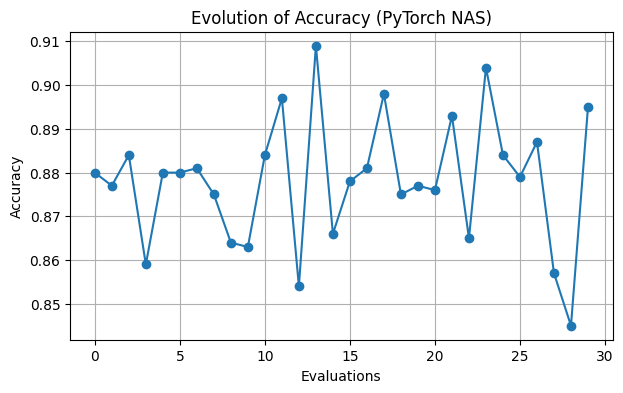

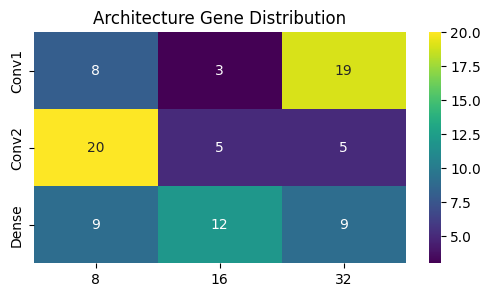

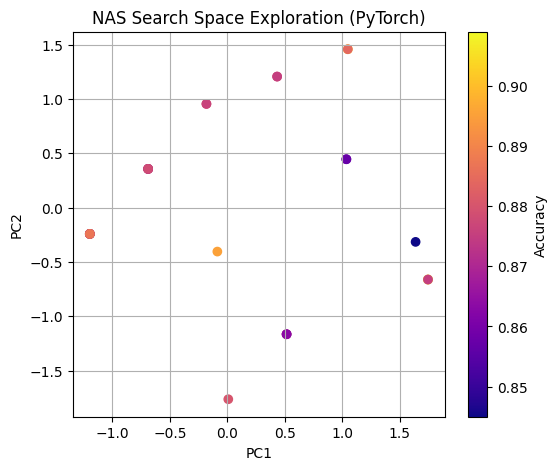

In [11]:
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

# =========================================================
# DEVICE
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================================================
# DATA (MNIST - reduced for speed)
# =========================================================
transform = transforms.Compose([
    transforms.ToTensor()
])

train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_data = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# subset for speed
x_train = torch.stack([train_data[i][0] for i in range(5000)])
y_train = torch.tensor([train_data[i][1] for i in range(5000)])

x_test = torch.stack([test_data[i][0] for i in range(1000)])
y_test = torch.tensor([test_data[i][1] for i in range(1000)])

train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(x_test, y_test), batch_size=64, shuffle=False)

# =========================================================
# SEARCH SPACE
# =========================================================
CONV_FILTERS = [8, 16, 32]
DENSE_UNITS = [32, 64, 128]

POP_SIZE = 6
GENERATIONS = 5
EPOCHS = 2

# =========================================================
# MODEL BUILDER (PyTorch)
# =========================================================
class Net(nn.Module):
    def __init__(self, f1, f2, dense):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, f1, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(f1, f2, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.flatten = nn.Flatten()

        self.fc = nn.Sequential(
            nn.Linear(self._get_flat_dim(f1, f2), dense),
            nn.ReLU(),
            nn.Linear(dense, 10)
        )

    def _get_flat_dim(self, f1, f2):
        with torch.no_grad():
            x = torch.zeros(1, 1, 28, 28)
            x = nn.Conv2d(1, f1, 3)(x)
            x = nn.ReLU()(x)
            x = nn.MaxPool2d(2)(x)

            x = nn.Conv2d(f1, f2, 3)(x)
            x = nn.ReLU()(x)
            x = nn.MaxPool2d(2)(x)

            return x.numel()

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x

# =========================================================
# FITNESS FUNCTION
# =========================================================
def fitness(genome):
    f1, f2, dense = genome

    model = Net(f1, f2, dense).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    model.train()
    for _ in range(EPOCHS):
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

    # evaluation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            preds = torch.argmax(out, dim=1)

            correct += (preds == yb).sum().item()
            total += yb.size(0)

    return correct / total

# =========================================================
# GENOME
# =========================================================
def random_genome():
    return (
        random.choice(CONV_FILTERS),
        random.choice(CONV_FILTERS),
        random.choice(DENSE_UNITS)
    )

# =========================================================
# EVOLUTION OPERATORS
# =========================================================
def crossover(a, b):
    return tuple(random.choice([x, y]) for x, y in zip(a, b))

def mutate(g):
    g = list(g)

    if random.random() < 0.5:
        g[0] = random.choice(CONV_FILTERS)
    if random.random() < 0.5:
        g[1] = random.choice(CONV_FILTERS)
    if random.random() < 0.5:
        g[2] = random.choice(DENSE_UNITS)

    return tuple(g)

# =========================================================
# INITIAL POPULATION
# =========================================================
population = [random_genome() for _ in range(POP_SIZE)]

history = []

best = None
best_acc = 0

# =========================================================
# EVOLUTION LOOP
# =========================================================
for gen in range(GENERATIONS):

    print(f"\nGeneration {gen}")

    scored = []

    for g in population:
        acc = fitness(g)
        scored.append((acc, g))

        print(f"  {g} -> acc={acc:.4f}")

        history.append((gen, acc, g))

        if acc > best_acc:
            best_acc = acc
            best = g

    scored.sort(reverse=True, key=lambda x: x[0])

    population = [g for _, g in scored[:POP_SIZE // 2]]

    while len(population) < POP_SIZE:
        p1, p2 = random.sample(population, 2)
        population.append(mutate(crossover(p1, p2)))

# =========================================================
# RESULTS
# =========================================================
print("\nBEST ARCHITECTURE:", best)
print("BEST ACCURACY:", best_acc)

# =========================================================
# VISUALIZATION 1: Accuracy Curve
# =========================================================
gens = [h[0] for h in history]
accs = [h[1] for h in history]

plt.figure(figsize=(7,4))
plt.plot(accs, marker='o')
plt.title("Evolution of Accuracy (PyTorch NAS)")
plt.xlabel("Evaluations")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

# =========================================================
# VISUALIZATION 2: Architecture Heatmap
# =========================================================
filters1 = [h[2][0] for h in history]
filters2 = [h[2][1] for h in history]
dense = [h[2][2] for h in history]

data = np.zeros((3, 3))

for f in filters1:
    data[0, CONV_FILTERS.index(f)] += 1

for f in filters2:
    data[1, CONV_FILTERS.index(f)] += 1

for d in dense:
    data[2, DENSE_UNITS.index(d)] += 1

plt.figure(figsize=(6,3))
sns.heatmap(
    data,
    annot=True,
    cmap="viridis",
    xticklabels=CONV_FILTERS,
    yticklabels=["Conv1", "Conv2", "Dense"]
)
plt.title("Architecture Gene Distribution")
plt.show()

# =========================================================
# VISUALIZATION 3: PCA Search Trajectory
# =========================================================
X = np.array([
    [
        CONV_FILTERS.index(h[2][0]),
        CONV_FILTERS.index(h[2][1]),
        DENSE_UNITS.index(h[2][2])
    ]
    for h in history
])

pca = PCA(n_components=2)
X2 = pca.fit_transform(X)

plt.figure(figsize=(6,5))
plt.scatter(X2[:,0], X2[:,1], c=accs, cmap='plasma')
plt.colorbar(label='Accuracy')
plt.title("NAS Search Space Exploration (PyTorch)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid()
plt.show()